<table align="left">
  <td>
    <a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab" title="Abrir y ejecutar en Google Colaboratory"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Abrir en Kaggle" title="Abrir y ejecutar en Kaggle"/></a>
  </td>
</table>

<br><br>

# Boosting moderno y optimización de hiperparámetros con validación correcta

**Curso:** Aprendizaje Automático — SI7009 - 1 (5553)  
**Sesión 2:** Boosting moderno y optimización de hiperparámetros con validación correcta  
**Universidad:** EAFIT  
**Dataset canónico:** Credit Card Fraud Detection  
**Profesor:** Marco Teran  

---

## Propósito del notebook

Este notebook materializa la lógica metodológica de la Sesión 2:

1. comparar familias boosted bajo condiciones homogéneas;
2. usar una métrica coherente con clasificación desbalanceada;
3. diseñar HPO con validación correcta;
4. diagnosticar Optuna sin tratarlo como magia;
5. contrastar class weights y SMOTE como hipótesis, no recetas;
6. seleccionar un threshold con evidencia out-of-fold;
7. evaluar en test reservado solo al final.

La pregunta central no es:

> ¿Qué modelo da el número más alto?

sino:

> ¿Qué pipeline merece continuar porque ganó bajo una comparación justa, con una métrica adecuada y una validación defendible?


---
## 📘 Cómo usar esta versión anotada

Esta es la versión **anotada para el docente** del notebook original. El código es el mismo (con una corrección, ver abajo), y se añadieron tres tipos de celdas:

| Marca | Qué es | ¿Se ejecuta? |
|---|---|---|
| **🧭 Guía docente** | Qué hace la celda siguiente, cómo explicarla, qué mirar en la salida, preguntas típicas de estudiantes y trampas. | No (texto) |
| **➕ Celda añadida** | Demos cortas que no estaban en el original, útiles para explicar la intuición (boosting "a mano", por qué accuracy engaña). | Sí, son opcionales e independientes |
| **⚠️ Ojo** | Detalles del notebook que pueden generar confusión o una pregunta difícil en clase. | No |

Si quieres entregar a los estudiantes el notebook "limpio", usa el original con la corrección de CatBoost; esta versión es tu guion.

### 🔧 Corrección aplicada al código

En las celdas **7.1** y **8.1** el original construía CatBoost con `class_weights=[1.0, scale_pos_weight_value]`. Con las versiones actuales de CatBoost y scikit-learn eso **rompe** la validación cruzada con el error:

```
RuntimeError: Cannot clone object CatBoostClassifier(...), as the constructor either does not set or modifies parameter class_weights
```

Y como la celda 7.2 falla, todo lo que viene después cae en cascada (`NameError`). Se reemplazó por `scale_pos_weight=scale_pos_weight_value`, que en CatBoost hace **exactamente lo mismo** para clasificación binaria (multiplica el peso de la clase 1). Si algún estudiante usa el notebook original y le falla la sección 7, esta es la causa.

### 🗺️ Mapa sugerido de la clase

| Bloque | Secciones | Idea que se tienen que llevar | Tiempo aprox. |
|---|---|---|---|
| Marco | 1 | La pregunta no es "qué modelo da más", sino "qué pipeline ganó de forma justa" | 10 min |
| Datos y métrica | 3–5 | Con 0.17 % de fraude, accuracy no dice nada; se usa PR-AUC | 15 min |
| Intuición de boosting | demo añadida + 6–7 | Boosting = muchos árboles pequeños que corrigen los errores de los anteriores | 25 min |
| HPO | 8–10 | Optuna solo optimiza la función objetivo que tú diseñas; el mejor trial está sesgado al alza | 25 min |
| Desbalance | 11–12 | Pesos y SMOTE son hipótesis que se comparan, no recetas | 15 min |
| Threshold y test | 13–15 | El modelo da scores; el threshold es una decisión de negocio. El test se toca una vez | 20 min |
| Cierre | 16–18 | Checklist y ejercicios | 10 min |

**Consejo práctico:** ejecuta el notebook completo **antes** de la clase (con `FAST_DEMO_MODE = True`) y guarda las salidas. En una prueba con un dataset del mismo tamaño que el real y 2 núcleos de CPU, la ejecución completa tomó del orden de los minutos indicados al final de esta guía (sección "Tiempos de ejecución"). En clase conviene mostrar las salidas ya calculadas y re-ejecutar solo celdas rápidas.

## Tabla de contenidos

1. Contrato metodológico de la sesión
2. Setup reproducible e instalación
3. Carga robusta del dataset
4. Auditoría de datos y desbalance
5. Split train/test y validación común
6. Baselines
7. Comparación base: XGBoost, LightGBM y CatBoost
8. HPO con Optuna y fallback
9. Diagnóstico de HPO
10. Modelo tuneado bajo CV común
11. Estrategias de desbalance: none, class weights y SMOTE
12. Selección provisional por CV
13. Out-of-fold scores y threshold policy
14. Evaluación final en test reservado
15. Importancia de variables
16. Registro final del experimento
17. Auditoría final del notebook
18. Ejercicios de extensión

> Ejecuta las celdas en orden. La meta no es solo obtener resultados, sino poder defender la comparación.


## 1. Contrato metodológico de la sesión

Durante todo el notebook se aplican estas reglas:

- No se usa `accuracy` como métrica principal.
- La métrica principal será `average_precision`, equivalente operativa a PR-AUC en `scikit-learn`.
- Las comparaciones deben usar el mismo esquema de validación.
- El test set no se usa para escoger hiperparámetros, familia, estrategia de desbalance ni threshold.
- SMOTE, class weights y modelos sin intervención se tratan como estrategias comparables, no como dogmas.
- Un modelo no se declara ganador solo por el mejor promedio: también se revisa estabilidad, complejidad, costo y coherencia metodológica.

### Qué se espera al finalizar

Debes poder explicar:

- por qué boosting moderno es relevante para problemas tabulares;
- qué diferencias prácticas importan entre XGBoost, LightGBM y CatBoost;
- qué controlan `learning_rate`, profundidad, número de árboles, regularización y subsampling;
- por qué Optuna optimiza una función objetivo diseñada por el analista;
- por qué PR-AUC es más apropiado que accuracy en fraude;
- cuándo class weights o SMOTE merecen conservarse;
- qué evidencia mínima permite decir que un pipeline ganó de forma defendible.


---
### 🧭 Guía docente — cómo presentar el contrato metodológico

Esta sección es el **corazón conceptual** de la clase. Todo el código posterior existe para cumplir estas reglas. Una forma de presentarlo:

> "Hoy no vamos a buscar el modelo con el número más alto. Vamos a diseñar una **competencia justa** entre modelos, con un árbitro (la métrica) adecuado y sin hacer trampa (sin mirar el test)."

Traducción de cada regla a lenguaje simple:

| Regla | Qué significa | Qué pasa si se viola |
|---|---|---|
| No usar `accuracy` | Con 0.17 % de fraude, decir siempre "no fraude" da 99.83 % de accuracy | Premias a un modelo inútil |
| Métrica principal = `average_precision` | Mide qué tan bien el modelo **ordena** los fraudes por encima de las transacciones normales, fijándose en la clase rara | — |
| Mismo esquema de validación | Todos los modelos se evalúan en exactamente los mismos 5 folds | La comparación depende de la suerte del split, no del modelo |
| El test no se usa para escoger nada | El test es el "examen final", se presenta una sola vez | El resultado en test deja de ser una estimación honesta (sobreajustas al test) |
| SMOTE / pesos como hipótesis | Se prueban y se comparan como cualquier otro candidato | Aplicar SMOTE "porque hay desbalance" sin evidencia |
| Ganar no es solo el mejor promedio | Mirar también la desviación entre folds, el costo y la complejidad | Declarar ganador a un modelo que ganó por ruido |

**Pregunta para abrir la clase:** "Si un modelo tiene 99.8 % de accuracy detectando fraude, ¿es bueno?" (La respuesta es: no se sabe; el modelo trivial ya tiene 99.83 %.)

## 2. Setup reproducible e instalación

Este notebook está diseñado para Colab, Kaggle y Jupyter local.

Librerías requeridas para el flujo base:

- `numpy`
- `pandas`
- `matplotlib`
- `scikit-learn`

Librerías recomendadas para el flujo completo:

- `xgboost`
- `lightgbm`
- `catboost`
- `optuna`
- `imbalanced-learn`

### Instalación en Colab o entorno local

Ejecuta la siguiente celda solo si alguna librería falta. Después de instalar, puede ser necesario reiniciar el runtime/kernel.

```bash
pip install -U xgboost lightgbm catboost optuna imbalanced-learn
```

Optuna puede fallar en algunos entornos por dependencias visuales, versiones antiguas de Python o conflictos con `plotly`. Si eso ocurre, el notebook usa un fallback con `RandomizedSearchCV` para preservar la lógica de HPO.


In [ ]:
# =============================================================================
# 2.1 Optional installation cell
# =============================================================================
# Uncomment and run only if needed.
# In Colab, restart the runtime after installation if imports still fail.

# !pip install -U -q xgboost lightgbm catboost optuna imbalanced-learn


---
### 🧭 Guía docente — imports y configuración global

Celda de "fontanería": no hace falta explicarla línea por línea. Puntos que sí vale la pena mencionar:

- `from __future__ import annotations` solo permite escribir las anotaciones de tipo (`Dict[str, Any]`, etc.) de forma más flexible. No afecta el comportamiento. Debe ser la primera instrucción de la celda.
- `warnings.filterwarnings("ignore")` **silencia todas las advertencias**. Es cómodo para clase, pero esconde avisos útiles (por ejemplo, LightGBM avisa cuando `num_leaves` es incompatible con `max_depth`, y sklearn avisa cuando la precisión queda indefinida porque el modelo no predijo ningún positivo). Si un resultado se ve raro, comenta esa línea y vuelve a ejecutar.
- `RANDOM_STATE = 42` fija las semillas para que los resultados sean **reproducibles**: mismo split, mismos folds, mismos trials de Optuna.
- `assert ... sklearn >= 1.2.0`: detiene el notebook si la versión es muy antigua.

In [2]:
# =============================================================================
# 2.2 Imports and global configuration
# =============================================================================

from __future__ import annotations

import os
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

import sklearn
from packaging import version

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

assert version.parse(sklearn.__version__) >= version.parse("1.2.0"), (
    "Este notebook requiere scikit-learn >= 1.2.0"
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print("Setup base importado correctamente.")


Python: 3.13.2
NumPy: 2.3.1
Pandas: 2.3.0
scikit-learn: 1.9.1
Setup base importado correctamente.


---
### 🧭 Guía docente — imports opcionales con try/except

Patrón defensivo: intenta importar cada librería y, si falla, guarda una bandera `*_AVAILABLE = False` en lugar de romper el notebook. Después, el resto del código pregunta por esas banderas para saltarse lo que no esté instalado.

**Qué mirar en la salida:** la tabla `package_availability`. Todas deberían estar en `True`. Si alguna aparece en `False`, instala con la celda 2.1 y **reinicia el kernel** (en Colab: *Runtime → Restart session*).

Solo se detiene si no hay **ninguna** de las tres librerías de boosting.

In [3]:
# =============================================================================
# 2.3 Optional package imports
# =============================================================================

XGBClassifier = None
LGBMClassifier = None
CatBoostClassifier = None
optuna = None
ImbPipeline = None
SMOTE = None

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBOOST_AVAILABLE = False
    print(f"XGBoost no disponible: {exc}")

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except Exception as exc:
    LIGHTGBM_AVAILABLE = False
    print(f"LightGBM no disponible: {exc}")

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception as exc:
    CATBOOST_AVAILABLE = False
    print(f"CatBoost no disponible: {exc}")

try:
    import optuna
    OPTUNA_AVAILABLE = True
except Exception as exc:
    OPTUNA_AVAILABLE = False
    print(f"Optuna no disponible: {exc}")

try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception as exc:
    IMBLEARN_AVAILABLE = False
    print(f"imbalanced-learn no disponible: {exc}")

package_availability = pd.DataFrame([
    {"package": "xgboost", "available": XGBOOST_AVAILABLE},
    {"package": "lightgbm", "available": LIGHTGBM_AVAILABLE},
    {"package": "catboost", "available": CATBOOST_AVAILABLE},
    {"package": "optuna", "available": OPTUNA_AVAILABLE},
    {"package": "imbalanced-learn", "available": IMBLEARN_AVAILABLE},
])

display(package_availability)

if not any([XGBOOST_AVAILABLE, LIGHTGBM_AVAILABLE, CATBOOST_AVAILABLE]):
    raise ImportError(
        "Se requiere al menos una librería boosted: xgboost, lightgbm o catboost. "
        "Instala las dependencias y reinicia el runtime."
    )


,package,available
0,xgboost,True
1,lightgbm,True
2,catboost,True
3,optuna,True
4,imbalanced-learn,True


---
### 🧭 Guía docente — configuración del experimento

Aquí están todas las "perillas" del experimento. Las más importantes:

- `N_SPLITS = 5`, `TEST_SIZE = 0.20`: 80 % para entrenar y validar (con 5 folds), 20 % reservado para el examen final.
- `FAST_DEMO_MODE = True`: versión de clase. El HPO usa **15 trials**, **3 folds** y una **submuestra de 80 000 filas**. En modo lento son 50 trials, 5 folds y todos los datos.
- `N_JOBS_OUTER = 1` y `N_JOBS_MODEL = -1`: el paralelismo se hace **dentro** de cada modelo (todos los núcleos), no entre folds. Si ambos usaran `-1`, habría paralelismo anidado (cada fold lanzando hilos por todos los núcleos), lo que suele ser más lento y puede colgar Colab.
- `CLASSIFICATION_CV_SCORING`: las 5 métricas que se calculan en cada fold.

**⚠️ Ojo, pregunta frecuente:** `pr_auc` y `roc_auc` se calculan a partir de **probabilidades** (no dependen de ningún umbral). En cambio, `f1`, `precision` y `recall` usan `model.predict()`, es decir, el **umbral fijo 0.5**. Por eso más adelante verás modelos con buen PR-AUC y un F1 malo: el problema es el umbral, no el modelo. Esto se resuelve en la sección 13.

- `model_registry` y `results_registry`: diccionarios donde se van guardando todos los modelos y tablas, para poder buscarlos por nombre después.

In [4]:
# =============================================================================
# 2.4 Notebook configuration
# =============================================================================

TARGET_COL = "Class"
NEGATIVE_LABEL = 0
POSITIVE_LABEL = 1

N_SPLITS = 5
TEST_SIZE = 0.20

# FAST_DEMO_MODE keeps the classroom run realistic.
# Set to False for a stronger but slower experiment.
FAST_DEMO_MODE = True

if FAST_DEMO_MODE:
    HPO_N_TRIALS = 15
    HPO_N_SPLITS = 3
    HPO_MAX_TRAIN_ROWS = 80_000
else:
    HPO_N_TRIALS = 50
    HPO_N_SPLITS = 5
    HPO_MAX_TRAIN_ROWS = None

# Avoid aggressive nested parallelism in classroom notebooks.
N_JOBS_OUTER = 1
N_JOBS_MODEL = -1

CLASSIFICATION_CV_SCORING = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}

model_registry: Dict[str, Any] = {}
results_registry: Dict[str, pd.DataFrame] = {}

print("Configuration ready.")
print(f"FAST_DEMO_MODE={FAST_DEMO_MODE}")
print(f"HPO_N_TRIALS={HPO_N_TRIALS}")
print(f"HPO_N_SPLITS={HPO_N_SPLITS}")


Configuration ready.
FAST_DEMO_MODE=True
HPO_N_TRIALS=15
HPO_N_SPLITS=3


---
### 🧭 Guía docente — funciones auxiliares

Son funciones de utilidad; basta con saber qué hace cada una:

| Función | Qué hace |
|---|---|
| `print_section` | Imprime un título bonito. |
| `require_columns` | Lanza un error claro si falta una columna. |
| `get_binary_class_counts` | Cuenta negativos, positivos y la tasa de positivos. |
| `find_credit_card_dataset` | Busca `creditcard.csv` en rutas típicas de local, Colab y Kaggle. |
| `audit_dataframe_schema` | Tabla con tipo de dato y faltantes por columna. |
| `add_stability_columns` | Agrega `relative_variability = std / media` (coeficiente de variación) y rankings. Un valor de 0.20 significa que el PR-AUC varía ±20 % entre folds. |
| `summarize_cv_results` | Convierte la salida de `cross_validate` en una fila: media y desviación de cada métrica. Usa `ddof=1` (desviación muestral, porque son solo 5 folds). |
| **`evaluate_model_cv`** | **La función clave**: corre `cross_validate` con el CV compartido y devuelve la fila resumen. Todos los modelos pasan por aquí, lo que garantiza la comparación justa. |
| `combine_and_sort_results` | Une tablas y ordena por PR-AUC. |
| `plot_cv_metric_comparison` | Barras horizontales con media ± desviación. |
| `infer_family_from_model_name` | Deduce la familia (xgboost/lightgbm/catboost) a partir del nombre. No se usa en el resto del notebook. |

**Mensaje para estudiantes:** encapsular la evaluación en **una sola función** es lo que garantiza que todos los modelos se midan igual.

In [5]:
# =============================================================================
# 2.5 General helper functions
# =============================================================================

def print_section(title: str, width: int = 96) -> None:
    """Print a readable section header."""
    print("\n" + "=" * width)
    print(title.center(width))
    print("=" * width)


def require_columns(
    dataframe: pd.DataFrame,
    required_columns: Sequence[str],
    dataframe_name: str = "dataframe",
) -> None:
    """Raise a clear error if required columns are missing."""
    missing = [col for col in required_columns if col not in dataframe.columns]
    if missing:
        raise ValueError(
            f"{dataframe_name} is missing required columns: {missing}. "
            f"Available columns: {list(dataframe.columns)}"
        )


def get_binary_class_counts(y_data: pd.Series) -> Dict[str, Any]:
    """Return class counts and prevalence for a binary target."""
    counts = y_data.value_counts().sort_index()
    negative_count = int(counts.get(NEGATIVE_LABEL, 0))
    positive_count = int(counts.get(POSITIVE_LABEL, 0))
    total_count = int(len(y_data))

    if total_count == 0:
        raise ValueError("Target vector is empty.")

    return {
        "total_count": total_count,
        "negative_count": negative_count,
        "positive_count": positive_count,
        "positive_rate": positive_count / total_count,
    }


def find_credit_card_dataset() -> Optional[Path]:
    """Search for creditcard.csv in common local, Colab, and Kaggle paths."""
    candidate_paths = [
        Path("creditcard.csv"),
        Path("data/creditcard.csv"),
        Path("../input/creditcardfraud/creditcard.csv"),
        Path("/kaggle/input/creditcardfraud/creditcard.csv"),
        Path("/content/creditcard.csv"),
        Path("/content/data/creditcard.csv"),
    ]

    for path in candidate_paths:
        if path.exists():
            return path

    return None


def audit_dataframe_schema(dataframe: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """Create a compact schema audit table."""
    rows = []
    for col in dataframe.columns:
        rows.append({
            "column": col,
            "dtype": str(dataframe[col].dtype),
            "missing_count": int(dataframe[col].isna().sum()),
            "missing_rate": float(dataframe[col].isna().mean()),
            "is_target": col == target_col,
        })
    return pd.DataFrame(rows)


def add_stability_columns(
    results: pd.DataFrame,
    metric_mean_col: str = "pr_auc_mean",
    metric_std_col: str = "pr_auc_std",
) -> pd.DataFrame:
    """Add simple stability indicators to a result table."""
    output = results.copy()
    output["relative_variability"] = output[metric_std_col] / output[metric_mean_col].replace(0, np.nan)
    output["rank_by_mean"] = output[metric_mean_col].rank(ascending=False, method="min")
    output["rank_by_stability"] = output["relative_variability"].rank(ascending=True, method="min")
    return output


def display_metric_columns(results: pd.DataFrame) -> pd.DataFrame:
    """Return the most useful metric columns for display."""
    preferred = [
        "model_group", "model",
        "pr_auc_mean", "pr_auc_std",
        "roc_auc_mean", "roc_auc_std",
        "precision_mean", "precision_std",
        "recall_mean", "recall_std",
        "f1_mean", "f1_std",
        "relative_variability",
        "fit_time_mean", "score_time_mean", "total_time_sec",
    ]
    cols = [col for col in preferred if col in results.columns]
    return results[cols].copy()


def summarize_cv_results(
    model_name: str,
    cv_result: Dict[str, np.ndarray],
    model_group: str,
) -> pd.DataFrame:
    """Convert sklearn cross_validate output into a one-row report."""
    row: Dict[str, Any] = {
        "model_group": model_group,
        "model": model_name,
    }

    for key, values in cv_result.items():
        if key.startswith("test_"):
            metric_name = key.replace("test_", "")
            row[f"{metric_name}_mean"] = float(np.mean(values))
            row[f"{metric_name}_std"] = float(np.std(values, ddof=1))

    row["fit_time_mean"] = float(np.mean(cv_result["fit_time"]))
    row["score_time_mean"] = float(np.mean(cv_result["score_time"]))

    return pd.DataFrame([row])


def evaluate_model_cv(
    estimator: Any,
    model_name: str,
    X_data: pd.DataFrame,
    y_data: pd.Series,
    cv_strategy: StratifiedKFold,
    scoring: Dict[str, str],
    model_group: str,
    n_jobs: int = N_JOBS_OUTER,
) -> pd.DataFrame:
    """Evaluate an estimator with a shared CV strategy."""
    start_time = time.time()

    cv_result = cross_validate(
        estimator=estimator,
        X=X_data,
        y=y_data,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=n_jobs,
        return_train_score=False,
        error_score="raise",
    )

    report = summarize_cv_results(
        model_name=model_name,
        cv_result=cv_result,
        model_group=model_group,
    )
    report["total_time_sec"] = float(time.time() - start_time)
    return report


def combine_and_sort_results(
    result_tables: Sequence[pd.DataFrame],
    sort_metric: str = "pr_auc_mean",
    ascending: bool = False,
) -> pd.DataFrame:
    """Combine result tables and sort by a metric."""
    non_empty = [table for table in result_tables if table is not None and not table.empty]
    if not non_empty:
        return pd.DataFrame()
    combined = pd.concat(non_empty, ignore_index=True)
    return combined.sort_values(sort_metric, ascending=ascending).reset_index(drop=True)


def plot_cv_metric_comparison(
    results: pd.DataFrame,
    metric_mean_col: str,
    metric_std_col: str,
    title: str,
    top_n: Optional[int] = None,
) -> None:
    """Plot mean ± std for a CV metric."""
    require_columns(results, ["model", metric_mean_col, metric_std_col], "results")

    plot_df = results.sort_values(metric_mean_col, ascending=True).copy()
    if top_n is not None:
        plot_df = plot_df.tail(top_n)

    fig, ax = plt.subplots(figsize=(10, max(4.5, 0.45 * len(plot_df))))
    ax.barh(plot_df["model"], plot_df[metric_mean_col], xerr=plot_df[metric_std_col], alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(f"{metric_mean_col} ± {metric_std_col}")
    ax.set_ylabel("Modelo / pipeline")
    plt.show()


def infer_family_from_model_name(model_name: str) -> Optional[str]:
    """Infer boosted family from a model name."""
    lowered = model_name.lower()
    if "xgboost" in lowered:
        return "xgboost"
    if "lightgbm" in lowered:
        return "lightgbm"
    if "catboost" in lowered:
        return "catboost"
    return None

print("Helper functions ready.")


Helper functions ready.


## 3. Carga robusta del dataset

El notebook espera el dataset `creditcard.csv` con la columna objetivo `Class`.

Escenarios soportados:

1. Kaggle: `/kaggle/input/creditcardfraud/creditcard.csv`
2. Colab: `/content/creditcard.csv` después de subirlo manualmente
3. Local: `creditcard.csv` o `data/creditcard.csv`

La clase positiva `Class = 1` representa fraude.


---
### 🧭 Guía docente — sobre el dataset

**Credit Card Fraud Detection** (Kaggle, transacciones europeas de septiembre de 2013):

- **284 807** transacciones, de las cuales **492** son fraude (≈ **0.172 %**).
- `Time`: segundos desde la primera transacción (cubre unos 2 días).
- `V1` … `V28`: variables **anonimizadas**, resultado de una PCA hecha por el banco. No tienen significado interpretable.
- `Amount`: monto de la transacción.
- `Class`: 1 = fraude, 0 = normal.

Si el archivo no está, la celda **se detiene a propósito** con `FileNotFoundError`. En Colab: sube `creditcard.csv` con el panel de archivos (queda en `/content/creditcard.csv`). En Kaggle: agrega el dataset *creditcardfraud* al notebook.

**Pregunta posible:** "¿Por qué no escalamos las variables?" Porque los árboles no lo necesitan: un split `V14 < -3.2` funciona igual a cualquier escala. Solo la regresión logística y SMOTE (que usa distancias) necesitan escalado, y por eso lo tienen dentro de su pipeline.

In [6]:
# =============================================================================
# 3.1 Dataset loading
# =============================================================================

dataset_path = find_credit_card_dataset()

if dataset_path is None:
    print_section("DATASET NOT FOUND")
    print("No se encontró creditcard.csv automáticamente.")
    print("Coloca el archivo en la carpeta actual, en data/creditcard.csv, o súbelo a Colab.")
    raise FileNotFoundError(
        "creditcard.csv was not found. Upload or place the file and rerun the notebook."
    )

print(f"Dataset found at: {dataset_path}")

df = pd.read_csv(dataset_path)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset found at: creditcard.csv
Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000,0
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0
2,1.000000,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000,0
3,1.000000,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0
4,2.000000,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000,0


---
### 🧭 Guía docente — validación del esquema

Controles de calidad antes de modelar: existe la columna objetivo, es binaria, todas las variables son numéricas y no hay faltantes. Con el dataset canónico todo pasa; el valor es **pedagógico**: "antes de entrenar, se audita".

In [7]:
# =============================================================================
# 3.2 Dataset schema and target audit
# =============================================================================

if TARGET_COL not in df.columns:
    raise ValueError(
        f"Expected target column '{TARGET_COL}' was not found. "
        f"Available columns: {list(df.columns)}"
    )

if df[TARGET_COL].nunique() != 2:
    raise ValueError(
        f"Expected a binary target in '{TARGET_COL}', found {df[TARGET_COL].nunique()} unique values."
    )

schema_audit = audit_dataframe_schema(df, TARGET_COL)

display(schema_audit)

non_numeric_predictors = [
    col for col in df.drop(columns=[TARGET_COL]).columns
    if not pd.api.types.is_numeric_dtype(df[col])
]

if non_numeric_predictors:
    raise ValueError(
        "This notebook expects numeric predictors for the canonical credit-card dataset. "
        f"Non-numeric columns found: {non_numeric_predictors}"
    )

if df.isna().any().any():
    missing_cols = df.columns[df.isna().any()].tolist()
    raise ValueError(
        f"Missing values detected in columns: {missing_cols}. "
        "Handle imputation before continuing."
    )

print("Dataset schema audit passed.")


,column,dtype,missing_count,missing_rate,is_target
0,Time,float64,0,0.000000,False
1,V1,float64,0,0.000000,False
2,V2,float64,0,0.000000,False
3,V3,float64,0,0.000000,False
4,V4,float64,0,0.000000,False
5,V5,float64,0,0.000000,False
6,V6,float64,0,0.000000,False
7,V7,float64,0,0.000000,False
8,V8,float64,0,0.000000,False
9,V9,float64,0,0.000000,False


Dataset schema audit passed.


## 4. Auditoría del desbalance

Antes de entrenar modelos, verificamos la prevalencia de fraude y mostramos por qué `accuracy` sería una brújula débil.


,class,label,count,rate,rate_percent
0,no_fraud,0,284315,0.998273,99.827251
1,fraud,1,492,0.001727,0.172749


Fraud prevalence: 0.00172749 (0.1727%)
Accuracy of an always-no-fraud classifier ≈ 0.99827251
Expected fraud recall of that trivial classifier = 0.0


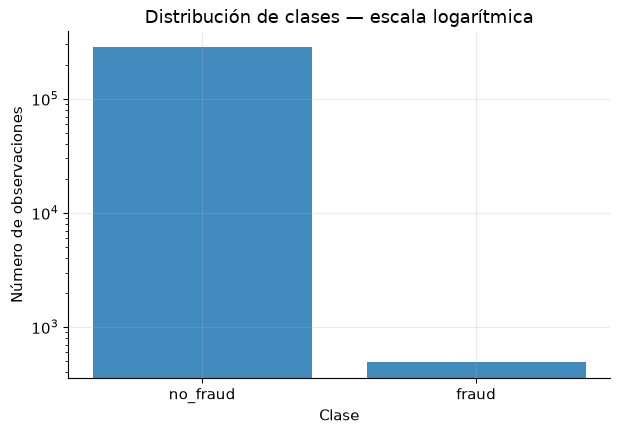

In [8]:
# =============================================================================
# 4.1 Class balance audit
# =============================================================================

y_full = df[TARGET_COL].astype(int)
class_stats = get_binary_class_counts(y_full)

class_balance = pd.DataFrame([
    {"class": "no_fraud", "label": NEGATIVE_LABEL, "count": class_stats["negative_count"]},
    {"class": "fraud", "label": POSITIVE_LABEL, "count": class_stats["positive_count"]},
])
class_balance["rate"] = class_balance["count"] / class_stats["total_count"]
class_balance["rate_percent"] = class_balance["rate"] * 100

display(class_balance)

majority_accuracy = 1.0 - class_stats["positive_rate"]

print(f"Fraud prevalence: {class_stats['positive_rate']:.8f} ({class_stats['positive_rate'] * 100:.4f}%)")
print(f"Accuracy of an always-no-fraud classifier ≈ {majority_accuracy:.8f}")
print("Expected fraud recall of that trivial classifier = 0.0")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(class_balance["class"], class_balance["count"], alpha=0.85)
ax.set_yscale("log")
ax.set_title("Distribución de clases — escala logarítmica")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de observaciones")
plt.show()


---
### 🧭 Guía docente — cómo explicar el desbalance

Números que conviene tener en la cabeza:

- Prevalencia de fraude ≈ 0.00173 (1 de cada ~580 transacciones).
- Un clasificador que **siempre** dice "no fraude" tiene accuracy ≈ 0.9983 y **recall de fraude = 0**.
- El gráfico usa **escala logarítmica**; en escala lineal la barra de fraude sería invisible.

La celda añadida de abajo muestra dos cosas que suelen costar entender: cuál es el PR-AUC "de azar" y por qué un ROC-AUC alto puede engañar.

### ¿Por qué PR-AUC y no ROC-AUC ni accuracy?

En machine learning y estadística, la prevalencia es simplemente la proporción de casos positivos reales que existen en tu conjunto de datos respecto al total.

Se calcula como:
$$\text{Prevalencia} = \frac{\text{Total de casos positivos}}{\text{Total de observaciones}}$$



En este caso de detección de fraude con transacciones muy desbalanceadas:

- 0.0017 (0.17 %): Significa que de cada 10 000 transacciones, solo unas 17 son fraudes reales y las otras 9 983 son legítimas.

- Línea base de PR-AUC:

    - En una curva ROC-AUC, un modelo que adivina completamente al azar obtiene 0.5 (la diagonal), sin importar el desbalance.

    - En una curva Precision-Recall (PR-AUC), un modelo que predice al azar obtiene una precisión promedio igual a la tasa natural de positivos (la prevalencia, en este caso 0.0017).

Por eso la prevalencia es el "punto cero" o línea base para evaluar si tu PR-AUC es realmente bueno o apenas mejor que tirar una moneda sesgada.

In [10]:
# ➕ Celda añadida: referencia de azar y trampa del ROC con desbalance
rng_demo = np.random.default_rng(RANDOM_STATE)
random_scores = rng_demo.random(len(y_full))

print("1) Modelo con scores aleatorios")
print(f"   Prevalencia de fraude       : {y_full.mean():.5f}")
print(f"   ROC-AUC con scores al azar  : {roc_auc_score(y_full, random_scores):.4f}   (referencia = 0.5)")
print(f"   PR-AUC  con scores al azar  : {average_precision_score(y_full, random_scores):.5f} (referencia = prevalencia)")

n_pos = int(y_full.sum())
n_neg = int(len(y_full) - n_pos)
tpr, fpr = 0.80, 0.01          # "80 % de fraudes detectados, 1 % de falsas alarmas"
tp = tpr * n_pos
fp = fpr * n_neg
print("\n2) Un punto 'excelente' de la curva ROC (TPR = 80 %, FPR = 1 %)")
print(f"   Fraudes detectados (TP)     : {tp:,.0f} de {n_pos:,}")
print(f"   Falsas alarmas (FP)         : {fp:,.0f} de {n_neg:,}")
print(f"   Precisión resultante        : {tp / (tp + fp):.3f}  -> ~{fp / tp:.0f} alertas falsas por cada fraude real")

1) Modelo con scores aleatorios
   Prevalencia de fraude       : 0.00173
   ROC-AUC con scores al azar  : 0.5044   (referencia = 0.5)
   PR-AUC  con scores al azar  : 0.00181 (referencia = prevalencia)

2) Un punto 'excelente' de la curva ROC (TPR = 80 %, FPR = 1 %)
   Fraudes detectados (TP)     : 394 de 492
   Falsas alarmas (FP)         : 2,843 de 284,315
   Precisión resultante        : 0.122  -> ~7 alertas falsas por cada fraude real


## 5. Split train/test y validación común

Se crea un test set estratificado que queda reservado hasta el final.

La selección de modelos, HPO, comparación de estrategias y threshold se hacen usando solo el training set.


---
### Split train/test

- `stratify=y` garantiza que train y test tengan la misma proporción de fraude (≈ 0.17 %). Sin estratificar, por azar podría quedar un test con muy pocos fraudes.
- Resultado esperado con el dataset real: train ≈ 227 845 filas (≈ 394 fraudes), test ≈ 56 962 filas (≈ **98 fraudes**).

**⚠️ Ojo, idea importante para el final de la clase:** el test tiene **menos de 100 fraudes**. Cada fraude acertado o fallado mueve el recall en ≈ 1 punto porcentual. Las métricas de test son, por lo tanto, **ruidosas**, y diferencias pequeñas no significan nada.

- La última línea verifica que ningún índice esté en ambos conjuntos (auditoría anti-leakage).
- **Limitación honesta:** el split es aleatorio, pero los datos tienen orden temporal (`Time`). En un sistema real de fraude se validaría con datos **futuros** (split temporal). Esto aparece en las limitaciones del final.

In [12]:
# =============================================================================
# 5.1 Train/test split
# =============================================================================

X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_rows = []
for split_name, split_y in {"train": y_train, "test": y_test}.items():
    stats = get_binary_class_counts(split_y)
    split_rows.append({
        "split": split_name,
        **stats,
        "positive_rate_percent": stats["positive_rate"] * 100,
    })

split_summary = pd.DataFrame(split_rows)
display(split_summary)

if set(X_train.index).intersection(set(X_test.index)):
    raise RuntimeError("Train and test indices overlap. Review split logic.")


,split,total_count,negative_count,positive_count,positive_rate,positive_rate_percent
0,train,227845,227451,394,0.001729,0.172925
1,test,56962,56864,98,0.001720,0.172045


---
### El objeto de validación cruzada compartido

Se crea **un solo** objeto `cv` y se reutiliza para todos los modelos. Como tiene `shuffle=True` con `random_state` fijo, los 5 folds son **idénticos** para todos los modelos: todos presentan exactamente los mismos "exámenes parciales".

- `StratifiedKFold` garantiza ≈ 79 fraudes por fold de validación (394 / 5).
- Con tan pocos positivos por fold, es normal ver **desviaciones estándar grandes** en PR-AUC (a veces 0.03–0.08 o más). Esto es clave para interpretar las comparaciones después.

In [13]:
# =============================================================================
# 5.2 Shared cross-validation strategy
# =============================================================================

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(cv)
print(CLASSIFICATION_CV_SCORING)


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
{'pr_auc': 'average_precision', 'roc_auc': 'roc_auc', 'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}


## 6. Baselines

Antes de comparar boosting, se construyen dos referencias:

1. `DummyClassifier`: muestra la trampa de una referencia trivial.
2. `LogisticRegression` con `class_weight="balanced"`: baseline clásico, simple y defendible.

Un modelo boosted debe superar una referencia seria, no solo un modelo trivial.


---
### 🧭 Guía docente — baselines

**`scale_pos_weight = negativos / positivos`** (≈ 577 con los datos reales). Es el peso que se le dará a cada fraude en los modelos con pesos: un fraude "pesa" como ~577 transacciones normales, lo que equilibra la contribución total de ambas clases a la función de pérdida.

Dos baselines:

1. **`DummyClassifier(most_frequent)`**: siempre predice 0. Resultado esperado: PR-AUC ≈ prevalencia (0.0017), ROC-AUC = 0.5, precision = recall = F1 = 0. Es la referencia del "no hacer nada".
2. **Regresión logística con `class_weight="balanced"`** dentro de un `Pipeline` con `StandardScaler`.
   - El escalador está **dentro** del pipeline, así que se ajusta solo con el bloque de entrenamiento de cada fold (sin leakage).
   - Es el baseline **serio**: si el boosting no le gana claramente, no se justifica su complejidad.

**Qué mirar en la salida:** la logística con pesos suele tener un **recall alto** (≈ 0.85–0.90) y una **precisión bajísima** (≈ 0.05 o menos) con umbral 0.5. Motivo: al darle tanto peso a la clase 1, las probabilidades del modelo se inflan y muchísimas transacciones pasan de 0.5. **El modelo no ordena mal, lo que está mal puesto es el umbral.** Buen momento para anticipar la sección 13.

**Pregunta posible:** "¿Por qué el dummy tiene PR-AUC 0.0017 y no 0?" Porque todas sus predicciones empatan; la curva PR colapsa en un solo punto cuya precisión es la prevalencia.

In [14]:
# =============================================================================
# 6.1 Baseline models
# =============================================================================

negative_count = int((y_train == NEGATIVE_LABEL).sum())
positive_count = int((y_train == POSITIVE_LABEL).sum())

if positive_count == 0:
    raise ValueError("No positive examples in training set. Stratified split failed.")

scale_pos_weight = negative_count / positive_count

print(f"Training negative count: {negative_count}")
print(f"Training positive count: {positive_count}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

baseline_models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "logistic_class_weight_balanced": Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2_000,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS_MODEL,
        )),
    ]),
}

baseline_reports = []

for name, estimator in baseline_models.items():
    print_section(f"Evaluating baseline: {name}")
    report = evaluate_model_cv(
        estimator=estimator,
        model_name=name,
        X_data=X_train,
        y_data=y_train,
        cv_strategy=cv,
        scoring=CLASSIFICATION_CV_SCORING,
        model_group="baseline",
        n_jobs=N_JOBS_OUTER,
    )
    baseline_reports.append(report)
    display(display_metric_columns(report))

baseline_results = combine_and_sort_results(baseline_reports, "pr_auc_mean", ascending=False)
baseline_results = add_stability_columns(baseline_results)

model_registry.update(baseline_models)
results_registry["baseline_results"] = baseline_results

display(display_metric_columns(baseline_results))


Training negative count: 227451
Training positive count: 394
scale_pos_weight: 577.2868

                            Evaluating baseline: dummy_most_frequent                            


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,score_time_mean,total_time_sec
0,baseline,dummy_most_frequent,0.001729,0.000010,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.026622,0.020455,0.272675



                      Evaluating baseline: logistic_class_weight_balanced                       


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,score_time_mean,total_time_sec
0,baseline,logistic_class_weight_balanced,0.757136,0.058245,0.982484,0.011368,0.062795,0.004042,0.913762,0.025765,0.117468,0.006907,0.417162,0.034686,2.293788


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,relative_variability,fit_time_mean,score_time_mean,total_time_sec
0,baseline,logistic_class_weight_balanced,0.757136,0.058245,0.982484,0.011368,0.062795,0.004042,0.913762,0.025765,0.117468,0.006907,0.076929,0.417162,0.034686,2.293788
1,baseline,dummy_most_frequent,0.001729,0.000010,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005675,0.026622,0.020455,0.272675


---
### 🧭 Guía docente — ¿Qué es boosting? (explicación antes de las librerías)

El notebook original salta directo a XGBoost/LightGBM/CatBoost. Conviene detenerse 10 minutos en la intuición.

**Bagging vs boosting**

| | Bagging (Random Forest) | Boosting (XGBoost, LightGBM, CatBoost) |
|---|---|---|
| Cómo se construyen los árboles | En **paralelo**, independientes | En **secuencia**: cada árbol corrige lo que falló el conjunto anterior |
| Tipo de árbol | Profundos (bajo sesgo, alta varianza) | **Pequeños** (profundidad 3–8), individualmente "débiles" |
| Qué reduce | Varianza (promediando) | Sesgo (corrigiendo errores paso a paso) |
| Riesgo | Poco sobreajuste al agregar árboles | **Sí puede sobreajustar** si se agregan demasiados árboles o si el `learning_rate` es alto |

**Gradient boosting en una frase:** empieza con una predicción constante; en cada paso entrena un árbol pequeño que predice **el error actual** (técnicamente, el gradiente negativo de la función de pérdida); suma ese árbol multiplicado por un factor pequeño (`learning_rate`); repite.

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

- $h_m$ = el árbol nuevo, entrenado sobre los residuos/gradientes.
- $\eta$ = `learning_rate`: qué tan grande es cada corrección.
- En clasificación binaria, $F(x)$ vive en escala de **log-odds** y la probabilidad es $\sigma(F(x))$. El "residuo" que aprende cada árbol es, esencialmente, $y - p$.

**Trade-off clave:** `learning_rate` pequeño + muchos árboles ≈ `learning_rate` grande + pocos árboles, pero el primero suele generalizar mejor (más lento). Por eso `learning_rate` y `n_estimators` **siempre se ajustan juntos**.

La celda siguiente lo muestra visualmente.

### ➕ Celda añadida (opcional) — Boosting "a mano" en 1D

Construimos boosting desde cero con árboles de profundidad 1 (*stumps*) para aproximar una curva con ruido. Cada árbol se entrena **sobre los residuos** del conjunto actual. Es regresión (no clasificación) para que se vea el mecanismo; la idea es la misma.

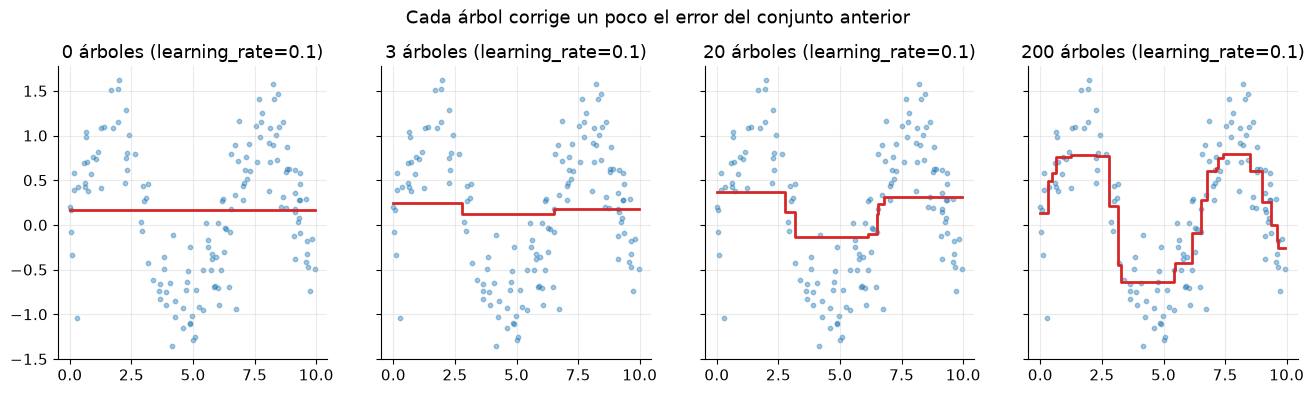

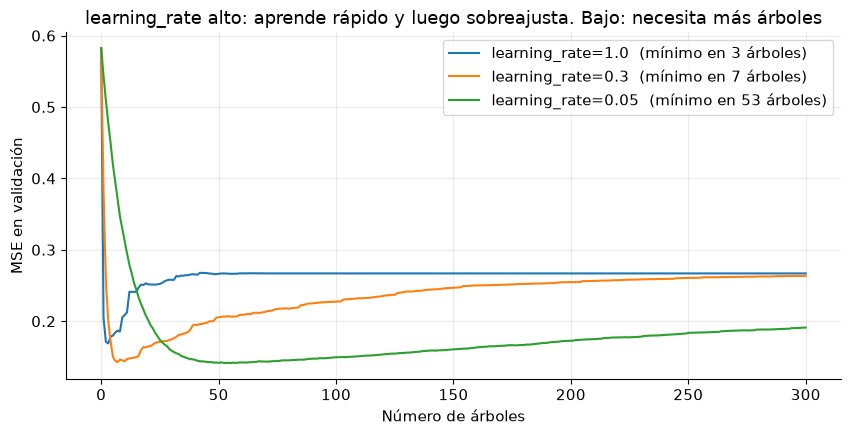

In [15]:
# ➕ Celda añadida: boosting construido a mano (regresión 1D, solo para intuición)
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

rng_demo = np.random.default_rng(0)
x_demo = np.sort(rng_demo.uniform(0, 10, 300)).reshape(-1, 1)
y_demo = np.sin(x_demo).ravel() + 0.35 * rng_demo.normal(size=300)

# mitad para entrenar, mitad para validar
idx = rng_demo.permutation(300)
tr, va = np.sort(idx[:150]), np.sort(idx[150:])


def manual_boosting(x_tr, y_tr, x_va, n_rounds, learning_rate, depth=1):
    pred_tr = np.full(len(y_tr), y_tr.mean())       # paso 0: predicción constante
    pred_va = np.full(len(x_va), y_tr.mean())
    history_tr, history_va = [pred_tr.copy()], [pred_va.copy()]
    for _ in range(n_rounds):
        residual = y_tr - pred_tr                    # lo que el ensemble todavía no explica
        tree = DecisionTreeRegressor(max_depth=depth).fit(x_tr, residual)
        pred_tr = pred_tr + learning_rate * tree.predict(x_tr)   # corrección pequeña
        pred_va = pred_va + learning_rate * tree.predict(x_va)
        history_tr.append(pred_tr.copy())
        history_va.append(pred_va.copy())
    return history_tr, history_va


# 1) Cómo evoluciona el ajuste al agregar árboles
hist_tr, _ = manual_boosting(x_demo[tr], y_demo[tr], x_demo[va], n_rounds=200, learning_rate=0.1)
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for ax, k in zip(axes, [0, 3, 20, 200]):
    ax.scatter(x_demo[tr], y_demo[tr], s=10, alpha=0.4)
    ax.step(x_demo[tr].ravel(), hist_tr[k], where="mid", color="C3", linewidth=2)
    ax.set_title(f"{k} árboles (learning_rate=0.1)")
plt.suptitle("Cada árbol corrige un poco el error del conjunto anterior", y=1.03)
plt.show()

# 2) learning_rate vs número de árboles: error de validación
fig, ax = plt.subplots(figsize=(10, 4.5))
for lr in [1.0, 0.3, 0.05]:
    h_tr, h_va = manual_boosting(x_demo[tr], y_demo[tr], x_demo[va], n_rounds=300, learning_rate=lr, depth=3)
    val_mse = [mean_squared_error(y_demo[va], p) for p in h_va]
    ax.plot(val_mse, label=f"learning_rate={lr}  (mínimo en {int(np.argmin(val_mse))} árboles)")
ax.set_xlabel("Número de árboles")
ax.set_ylabel("MSE en validación")
ax.set_title("learning_rate alto: aprende rápido y luego sobreajusta. Bajo: necesita más árboles")
ax.legend()
plt.show()

**Cómo leer la demo:**

- Con 0 árboles, la predicción es una línea plana (la media). Con cada árbol, la curva se va ajustando.
- En el segundo gráfico, con `learning_rate=1.0` el error de validación baja muy rápido y **luego sube** (sobreajuste). Con `0.05` baja lento, pero llega a un error similar o menor y es más estable.
- **Mensaje:** en boosting, *más árboles no siempre es mejor*. Por eso `n_estimators` es un hiperparámetro y en la práctica se usa *early stopping*.

## 7. Comparación base de familias boosted

Comparamos XGBoost, LightGBM y CatBoost cuando estén disponibles.

Reglas:

- mismo `X_train`;
- mismo `StratifiedKFold`;
- misma métrica principal;
- mismo tratamiento inicial de desbalance mediante class weights o equivalente;
- test set intacto.


---
### 🧭 Guía docente — las tres familias y sus diferencias prácticas

| | **XGBoost** | **LightGBM** | **CatBoost** |
|---|---|---|---|
| Origen | Chen & Guestrin, 2016 | Microsoft, 2017 | Yandex, 2017 |
| Cómo crece el árbol | **Por niveles** (*level-wise*): llena cada nivel antes de bajar | **Por hojas** (*leaf-wise*): siempre divide la hoja que más reduce la pérdida → árboles asimétricos | **Árboles simétricos** (*oblivious*): la misma condición en todo un nivel |
| Control de complejidad principal | `max_depth` | `num_leaves` (y `max_depth` como tope) | `depth` |
| Fortaleza típica | Robusto y muy usado; regularización explícita (`gamma`, `reg_lambda`, `reg_alpha`) | Muy rápido en datasets grandes (histogramas, leaf-wise) | Variables **categóricas** nativas y *ordered boosting* contra el leakage del target encoding; buenos defaults |
| Riesgo típico | — | Leaf-wise sobreajusta más fácil con pocos datos (controlar `min_child_samples`) | Más lento de entrenar en CPU |

En este dataset todas las variables son numéricas, así que la ventaja principal de CatBoost (categóricas) no aparece.

**Equivalencias de hiperparámetros entre librerías:**

| Concepto | XGBoost | LightGBM | CatBoost |
|---|---|---|---|
| Número de árboles | `n_estimators` | `n_estimators` | `iterations` |
| Tamaño de cada corrección | `learning_rate` | `learning_rate` | `learning_rate` |
| Complejidad del árbol | `max_depth` | `num_leaves`, `max_depth` | `depth` |
| Mínimo de datos por hoja | `min_child_weight` | `min_child_samples` | `min_data_in_leaf` |
| Regularización L2 | `reg_lambda` | `reg_lambda` | `l2_leaf_reg` |
| Submuestreo de filas | `subsample` | `subsample` + `subsample_freq` | `subsample` / `bagging_temperature` |
| Submuestreo de columnas | `colsample_bytree` | `colsample_bytree` | `rsm` |
| Peso de la clase positiva | `scale_pos_weight` | `class_weight` o `scale_pos_weight` | `scale_pos_weight` / `class_weights` |

---
### 🧭 Guía docente — la "fábrica" de modelos base (celda 7.1)

Se construyen los tres modelos con **ajustes moderados y comparables**: 250 árboles, `learning_rate=0.05`, profundidad moderada, 90 % de filas y columnas por árbol. No están tuneados; la idea es compararlos **en igualdad de condiciones**.

Detalles que conviene saber:

- **Cómo recibe cada librería el peso de la clase positiva:**
  - XGBoost: `scale_pos_weight=577` → cada fraude pesa 577.
  - LightGBM: `class_weight="balanced"` → pesos $n/(2 n_c)$: normal ≈ 0.5, fraude ≈ 289. **La proporción es la misma (≈ 577)**, así que el efecto es equivalente.
  - CatBoost: `scale_pos_weight=577`.
- **⚠️ Ojo, confusión frecuente:** `eval_metric="aucpr"` (XGBoost) y `eval_metric="PRAUC"` (CatBoost) **no cambian el entrenamiento**. El modelo siempre minimiza log-loss. `eval_metric` solo se usa para monitorear un `eval_set` o para *early stopping*, y aquí no se usa ninguno de los dos. El PR-AUC que importa lo calcula `cross_validate`.
- `tree_method="hist"` (XGBoost): agrupa cada variable en ~256 bins (histogramas). Es mucho más rápido que el método exacto y es el estándar moderno.
- LightGBM: `subsample` solo tiene efecto si `subsample_freq > 0` (aquí 1 = remuestrear en cada iteración). Es un error común poner `subsample=0.8` y olvidar `subsample_freq`.
- CatBoost: `verbose=False` y `allow_writing_files=False` evitan que imprima cientos de líneas y que cree la carpeta `catboost_info/`.

In [16]:
# =============================================================================
# 7.1 Base boosted model factory
# =============================================================================

def build_base_boosting_models(
    scale_pos_weight_value: float,
    random_state: int = RANDOM_STATE,
) -> Dict[str, Any]:
    """Build initial boosted models with comparable moderate settings."""
    models: Dict[str, Any] = {}

    if XGBOOST_AVAILABLE and XGBClassifier is not None:
        models["xgboost_base_class_weight"] = XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.90,
            colsample_bytree=0.90,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="aucpr",
            scale_pos_weight=scale_pos_weight_value,
            random_state=random_state,
            n_jobs=N_JOBS_MODEL,
            tree_method="hist",
        )

    if LIGHTGBM_AVAILABLE and LGBMClassifier is not None:
        models["lightgbm_base_class_weight"] = LGBMClassifier(
            n_estimators=250,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=40,
            subsample=0.90,
            subsample_freq=1,
            colsample_bytree=0.90,
            reg_lambda=1.0,
            objective="binary",
            class_weight="balanced",
            random_state=random_state,
            n_jobs=N_JOBS_MODEL,
            verbosity=-1,
        )

    if CATBOOST_AVAILABLE and CatBoostClassifier is not None:
        models["catboost_base_class_weight"] = CatBoostClassifier(
            iterations=250,
            depth=5,
            learning_rate=0.05,
            l2_leaf_reg=3.0,
            loss_function="Logloss",
            eval_metric="PRAUC",
            # CORRECCIÓN: el original usaba class_weights=[1.0, w], que rompe sklearn.clone
            # con CatBoost reciente. scale_pos_weight=w es equivalente en binario.
            scale_pos_weight=scale_pos_weight_value,
            random_seed=random_state,
            verbose=False,
            allow_writing_files=False,
            thread_count=N_JOBS_MODEL,
        )

    return models


boosting_models = build_base_boosting_models(
    scale_pos_weight_value=scale_pos_weight,
    random_state=RANDOM_STATE,
)

if not boosting_models:
    raise ImportError("No boosted model libraries are available.")

model_registry.update(boosting_models)

print("Available boosted models:")
for name in boosting_models:
    print(f"- {name}")


Available boosted models:
- xgboost_base_class_weight
- lightgbm_base_class_weight
- catboost_base_class_weight


---
### 🧭 Guía docente — evaluación de las familias boosted (celda 7.2)

Cada modelo se evalúa con `evaluate_model_cv` → 5 folds × 3 modelos = 15 entrenamientos. Es una de las celdas más lentas; mejor tenerla ejecutada de antemano.

**Cómo leer la tabla y el gráfico:**

1. **Primero `pr_auc_mean`**: los modelos boosted deberían superar a la logística. En el dataset real, típicamente los boosted quedan en torno a 0.8–0.87 y la logística claramente más abajo (los valores exactos dependen de la versión y la semilla).
2. **Luego `pr_auc_std`**: si la diferencia entre dos modelos es menor que su desviación estándar entre folds, **no hay evidencia de que uno sea mejor**. Regla práctica para clase: "si las barras de error se superponen mucho, es un empate técnico".
3. **`roc_auc_mean`** suele estar por encima de 0.95 para todos y **casi no discrimina** entre modelos. Es buena ilustración de por qué no es la métrica principal aquí.
4. **`precision` / `recall` / `f1`** están medidas con umbral 0.5 y dependen mucho del peso de clase. No sirven para escoger modelo.
5. **`fit_time_mean`**: costo. Un modelo 5 veces más lento con el mismo PR-AUC no es mejor.

**Pregunta posible:** "¿Por qué CatBoost, que tiene fama de ser el mejor, no gana?" Porque no hay un ganador universal: depende de los datos, de los hiperparámetros y del ruido. Por eso se compara.


                      Evaluating boosted model: xgboost_base_class_weight                       


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,score_time_mean,total_time_sec
0,boosting_base,xgboost_base_class_weight,0.828156,0.028044,0.982153,0.011862,0.583069,0.043357,0.847744,0.042802,0.688951,0.019362,1.766827,0.072706,9.249448



                      Evaluating boosted model: lightgbm_base_class_weight                      


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,score_time_mean,total_time_sec
0,boosting_base,lightgbm_base_class_weight,0.855418,0.022684,0.980538,0.014057,0.865863,0.047522,0.827459,0.040391,0.844579,0.011709,1.332861,0.194411,7.698688



                      Evaluating boosted model: catboost_base_class_weight                      


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,score_time_mean,total_time_sec
0,boosting_base,catboost_base_class_weight,0.791592,0.025223,0.979975,0.011780,0.551718,0.032261,0.855404,0.047640,0.669168,0.011309,6.464217,0.044094,32.602343


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,relative_variability,fit_time_mean,score_time_mean,total_time_sec
0,boosting_base,lightgbm_base_class_weight,0.855418,0.022684,0.980538,0.014057,0.865863,0.047522,0.827459,0.040391,0.844579,0.011709,0.026518,1.332861,0.194411,7.698688
1,boosting_base,xgboost_base_class_weight,0.828156,0.028044,0.982153,0.011862,0.583069,0.043357,0.847744,0.042802,0.688951,0.019362,0.033863,1.766827,0.072706,9.249448
2,boosting_base,catboost_base_class_weight,0.791592,0.025223,0.979975,0.011780,0.551718,0.032261,0.855404,0.047640,0.669168,0.011309,0.031864,6.464217,0.044094,32.602343
3,baseline,logistic_class_weight_balanced,0.757136,0.058245,0.982484,0.011368,0.062795,0.004042,0.913762,0.025765,0.117468,0.006907,0.076929,0.417162,0.034686,2.293788
4,baseline,dummy_most_frequent,0.001729,0.000010,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005675,0.026622,0.020455,0.272675


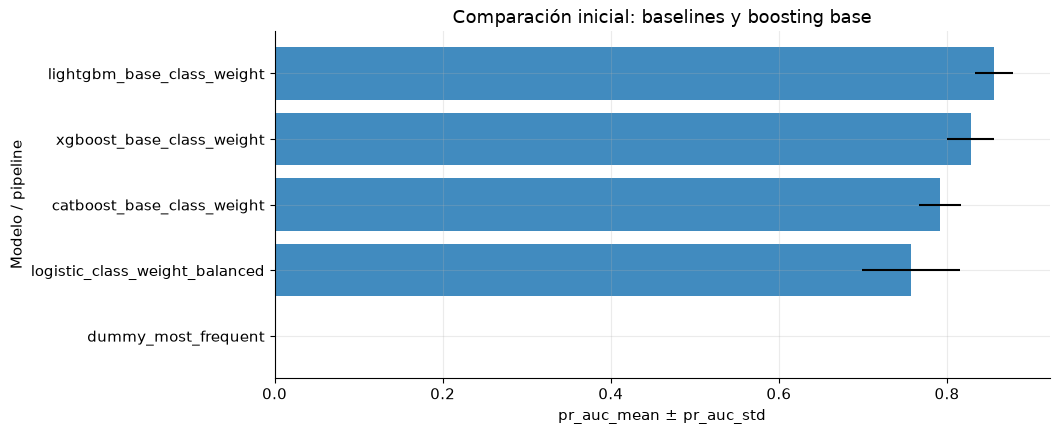

In [17]:
# =============================================================================
# 7.2 Evaluate base boosted families
# =============================================================================

boosting_reports = []

for name, estimator in boosting_models.items():
    print_section(f"Evaluating boosted model: {name}")
    report = evaluate_model_cv(
        estimator=estimator,
        model_name=name,
        X_data=X_train,
        y_data=y_train,
        cv_strategy=cv,
        scoring=CLASSIFICATION_CV_SCORING,
        model_group="boosting_base",
        n_jobs=N_JOBS_OUTER,
    )
    boosting_reports.append(report)
    display(display_metric_columns(report))

boosting_base_results = combine_and_sort_results(boosting_reports, "pr_auc_mean", ascending=False)
boosting_base_results = add_stability_columns(boosting_base_results)

initial_comparison = combine_and_sort_results(
    [baseline_results, boosting_base_results],
    sort_metric="pr_auc_mean",
    ascending=False,
)
initial_comparison = add_stability_columns(initial_comparison)

results_registry["boosting_base_results"] = boosting_base_results
results_registry["initial_comparison"] = initial_comparison

display(display_metric_columns(initial_comparison))

plot_cv_metric_comparison(
    results=initial_comparison,
    metric_mean_col="pr_auc_mean",
    metric_std_col="pr_auc_std",
    title="Comparación inicial: baselines y boosting base",
    top_n=10,
)


---
### 🧭 Guía docente — elección de la familia para HPO

**⚠️ Ojo:** esta función **no** elige la mejor familia según los resultados anteriores. Simplemente toma XGBoost si está instalado (luego LightGBM, luego CatBoost). El propio notebook lo aclara: es una elección **docente**, para mostrar el método de HPO con una sola familia y no triplicar el tiempo.

Si un estudiante pregunta "¿por qué no tuneamos la que ganó?", la respuesta honesta es: "podríamos, y es el Ejercicio 2; hoy lo importante es el procedimiento".

In [18]:
# =============================================================================
# 7.3 Choose HPO family
# =============================================================================

def choose_hpo_family() -> str:
    """Choose a family for HPO demonstration based on availability."""
    if XGBOOST_AVAILABLE:
        return "xgboost"
    if LIGHTGBM_AVAILABLE:
        return "lightgbm"
    if CATBOOST_AVAILABLE:
        return "catboost"
    raise ImportError("No supported boosted model family is available.")


HPO_FAMILY = choose_hpo_family()

print(f"Selected HPO family: {HPO_FAMILY}")
print(
    "Esta selección es docente y práctica; no significa que esa familia gane siempre. "
    "Lo importante es preservar la metodología de HPO."
)


Selected HPO family: xgboost
Esta selección es docente y práctica; no significa que esa familia gane siempre. Lo importante es preservar la metodología de HPO.


## 8. HPO con Optuna y fallback

Optuna no reemplaza el criterio metodológico. Solo optimiza la función objetivo que definimos.

La función objetivo debe incluir:

- métrica coherente: `average_precision`;
- validación correcta: `StratifiedKFold`;
- espacio de búsqueda razonable;
- ausencia total de test set;
- lectura de promedio y variabilidad.


---
### 🧭 Guía docente — qué es HPO y cómo funciona Optuna

**Parámetros vs hiperparámetros:** los *parámetros* los aprende el modelo (los splits y los valores de las hojas). Los *hiperparámetros* los fijamos nosotros antes de entrenar (`learning_rate`, `max_depth`...). HPO = buscar automáticamente buenos hiperparámetros.

**Optuna en 4 conceptos:**

| Concepto | Qué es |
|---|---|
| `study` | El experimento completo de búsqueda. `direction="maximize"` porque queremos PR-AUC alto. |
| `trial` | Una configuración de hiperparámetros evaluada. |
| `objective(trial)` | **La función que escribimos nosotros**: recibe un trial, propone hiperparámetros, entrena con CV y devuelve un número. Optuna solo intenta que ese número suba. |
| `sampler` (TPE) | La estrategia para proponer el siguiente trial. |

**TPE (Tree-structured Parzen Estimator) sin fórmulas:** separa los trials ya hechos en "buenos" (mejor ~10–25 %) y "malos", estima en qué regiones del espacio se concentran los buenos, y propone el siguiente punto donde la proporción buenos/malos es mayor. Es una búsqueda **que aprende** de los intentos anteriores, a diferencia de Random Search.

**⚠️ Ojo, detalle clave con 15 trials:** por defecto TPE hace los **primeros 10 trials al azar** (`n_startup_trials=10`) para explorar. Con `HPO_N_TRIALS = 15` en modo rápido, solo **5 trials** son realmente guiados por TPE. En clase, la búsqueda se parece mucho a un random search. No es un error, pero hay que decirlo si alguien pregunta "¿dónde está la inteligencia de Optuna?".

**Frase para la clase:** "Optuna no sabe nada de fraude. Si le das una función objetivo con accuracy o que mira el test, optimizará con entusiasmo la cosa equivocada."

---
### 🧭 Guía docente — muestra para HPO y espacios de búsqueda (celda 8.1)

Esta celda prepara todo lo que necesita el HPO. Tiene cuatro partes:

**1. `hpo_cv`**: otro `StratifiedKFold`, con 3 folds en modo rápido (para ahorrar tiempo).

**2. `make_stratified_sample`**: toma una submuestra **estratificada** de 80 000 filas del *train* (no del test) para acelerar el HPO. Con ≈ 227 000 filas de train, se usa ≈ 35 % de los datos, lo que deja ≈ 138 fraudes, ≈ 46 por fold de validación. **Consecuencia:** los scores del HPO son más ruidosos que los del CV principal. Por eso luego (sección 10) el modelo tuneado se re-evalúa con el CV completo.

`hpo_scale_pos_weight` se recalcula sobre la muestra (debería salir casi igual, ≈ 577, gracias a la estratificación).

**3. Espacios de búsqueda (`sample_xgboost_params` etc.)**: `trial.suggest_int` / `trial.suggest_float` le dicen a Optuna el rango de cada hiperparámetro.

- `log=True` (en `learning_rate`, `reg_lambda`, `reg_alpha`): muestrea **uniforme en escala logarítmica**. Pasar de 0.01 a 0.02 importa tanto como pasar de 0.1 a 0.2. Sin `log=True`, casi todos los trials caerían en valores "grandes".
- Rangos XGBoost, qué controla cada uno:

| Hiperparámetro | Rango | Efecto al subirlo |
|---|---|---|
| `n_estimators` | 150–650 | Más correcciones (más capacidad y más tiempo) |
| `max_depth` | 2–8 | Árboles más complejos (interacciones de más variables) |
| `learning_rate` | 0.01–0.2 (log) | Correcciones más grandes → aprende rápido, más riesgo de sobreajuste |
| `subsample` | 0.65–1.0 | Más filas por árbol (menos aleatoriedad) |
| `colsample_bytree` | 0.65–1.0 | Más columnas por árbol |
| `min_child_weight` | 1–12 | **Más conservador**: exige más "masa" en cada hoja |
| `gamma` | 0–5 | **Más conservador**: un split debe mejorar la pérdida al menos `gamma` |
| `reg_lambda` (L2) | 0.1–20 (log) | **Más conservador**: encoge los valores de las hojas |
| `reg_alpha` (L1) | 1e-4–5 (log) | **Más conservador**: puede anular hojas pequeñas |

**⚠️ Ojo con pesos grandes:** con `scale_pos_weight ≈ 577`, cada fraude aporta mucha "masa" (hessiano) a la hoja, así que `min_child_weight` se alcanza con muy pocos fraudes. Es una interacción sutil entre pesos y regularización.

- LightGBM: `max_depth` va de -1 a 10; en LightGBM **-1 y 0 significan "sin límite"**.

**4. `get_default_hpo_params_for_family` y `build_trial_model`**: los valores por defecto (iguales a los de la sección 7) y una función que arma el modelo de cualquier familia a partir de un diccionario de hiperparámetros, siempre **con** pesos de clase.

In [19]:
# =============================================================================
# 8.1 HPO sampling and model-building helpers
# =============================================================================

hpo_cv = StratifiedKFold(
    n_splits=HPO_N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)


def make_stratified_sample(
    X_data: pd.DataFrame,
    y_data: pd.Series,
    max_rows: Optional[int],
    random_state: int = RANDOM_STATE,
) -> Tuple[pd.DataFrame, pd.Series]:
    """Create a stratified sample for faster HPO demonstrations."""
    if max_rows is None or len(X_data) <= max_rows:
        return X_data.copy(), y_data.copy()
    if max_rows <= 0:
        raise ValueError("max_rows must be positive or None.")

    train_size = max_rows / len(X_data)
    X_sample, _, y_sample, _ = train_test_split(
        X_data,
        y_data,
        train_size=train_size,
        stratify=y_data,
        random_state=random_state,
    )
    return X_sample.copy(), y_sample.copy()


X_hpo, y_hpo = make_stratified_sample(
    X_data=X_train,
    y_data=y_train,
    max_rows=HPO_MAX_TRAIN_ROWS,
    random_state=RANDOM_STATE,
)

hpo_stats = get_binary_class_counts(y_hpo)
hpo_scale_pos_weight = hpo_stats["negative_count"] / hpo_stats["positive_count"]

hpo_sample_summary = pd.DataFrame([
    {"dataset": "full_training_set", **get_binary_class_counts(y_train)},
    {"dataset": "hpo_training_sample", **hpo_stats},
])
display(hpo_sample_summary)

print(f"HPO scale_pos_weight: {hpo_scale_pos_weight:.4f}")


def sample_xgboost_params(trial: Any) -> Dict[str, Any]:
    """Sample a compact XGBoost search space."""
    return {
        "n_estimators": trial.suggest_int("n_estimators", 150, 650),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "subsample": trial.suggest_float("subsample", 0.65, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.00),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 12.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 20.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
    }


def sample_lightgbm_params(trial: Any) -> Dict[str, Any]:
    """Sample a compact LightGBM search space."""
    return {
        "n_estimators": trial.suggest_int("n_estimators", 150, 650),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", -1, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 120),
        "subsample": trial.suggest_float("subsample", 0.65, 1.00),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.00),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 20.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
    }


def sample_catboost_params(trial: Any) -> Dict[str, Any]:
    """Sample a compact CatBoost search space."""
    return {
        "iterations": trial.suggest_int("iterations", 150, 650),
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 5.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
    }


def sample_params_for_family(trial: Any, family: str) -> Dict[str, Any]:
    """Route Optuna sampling to the selected model family."""
    if family == "xgboost":
        return sample_xgboost_params(trial)
    if family == "lightgbm":
        return sample_lightgbm_params(trial)
    if family == "catboost":
        return sample_catboost_params(trial)
    raise ValueError(f"Unsupported family: {family}")


def get_default_hpo_params_for_family(family: str) -> Dict[str, Any]:
    """Return compact defaults compatible with build_trial_model."""
    if family == "xgboost":
        return {
            "n_estimators": 250,
            "max_depth": 4,
            "learning_rate": 0.05,
            "subsample": 0.90,
            "colsample_bytree": 0.90,
            "min_child_weight": 1.0,
            "gamma": 0.0,
            "reg_lambda": 1.0,
            "reg_alpha": 0.0,
        }
    if family == "lightgbm":
        return {
            "n_estimators": 250,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": -1,
            "min_child_samples": 40,
            "subsample": 0.90,
            "subsample_freq": 1,
            "colsample_bytree": 0.90,
            "reg_lambda": 1.0,
            "reg_alpha": 0.0,
        }
    if family == "catboost":
        return {
            "iterations": 250,
            "depth": 5,
            "learning_rate": 0.05,
            "l2_leaf_reg": 3.0,
            "random_strength": 1.0,
            "bagging_temperature": 1.0,
        }
    raise ValueError(f"Unsupported family: {family}")


def build_trial_model(
    family: str,
    params: Dict[str, Any],
    scale_pos_weight_value: float,
    random_state: int = RANDOM_STATE,
    n_jobs_model: int = N_JOBS_MODEL,
) -> Any:
    """Build a boosted model for a single HPO configuration."""
    if family == "xgboost":
        if not XGBOOST_AVAILABLE or XGBClassifier is None:
            raise ImportError("XGBoost is not available.")
        return XGBClassifier(
            **params,
            objective="binary:logistic",
            eval_metric="aucpr",
            scale_pos_weight=scale_pos_weight_value,
            random_state=random_state,
            n_jobs=n_jobs_model,
            tree_method="hist",
        )

    if family == "lightgbm":
        if not LIGHTGBM_AVAILABLE or LGBMClassifier is None:
            raise ImportError("LightGBM is not available.")
        return LGBMClassifier(
            **params,
            objective="binary",
            class_weight="balanced",
            random_state=random_state,
            n_jobs=n_jobs_model,
            verbosity=-1,
        )

    if family == "catboost":
        if not CATBOOST_AVAILABLE or CatBoostClassifier is None:
            raise ImportError("CatBoost is not available.")
        return CatBoostClassifier(
            **params,
            loss_function="Logloss",
            eval_metric="PRAUC",
            # CORRECCIÓN: el original usaba class_weights=[1.0, w], que rompe sklearn.clone
            # con CatBoost reciente. scale_pos_weight=w es equivalente en binario.
            scale_pos_weight=scale_pos_weight_value,
            random_seed=random_state,
            verbose=False,
            allow_writing_files=False,
            thread_count=n_jobs_model,
        )

    raise ValueError(f"Unsupported family: {family}")


,dataset,total_count,negative_count,positive_count,positive_rate
0,full_training_set,227845,227451,394,0.001729
1,hpo_training_sample,80000,79862,138,0.001725


HPO scale_pos_weight: 578.7101


---
### 🧭 Guía docente — la función objetivo y el fallback (celda 8.2)

**La función `objective(trial)` es lo más importante de la sección.** Léela con los estudiantes línea por línea:

1. `sample_params_for_family(trial, ...)`: Optuna propone hiperparámetros.
2. `build_trial_model(...)`: se construye el modelo con esos hiperparámetros.
3. `cross_validate(... X_hpo, y_hpo, cv=hpo_cv, scoring average_precision)`: **la validación vive dentro de la función objetivo**. Solo usa datos de train. El test no aparece por ningún lado.
4. `trial.set_user_attr(...)`: guarda información extra (scores por fold, desviación, tiempo) para diagnosticar después. Optuna no la usa para optimizar.
5. `return mean(fold_scores)`: el número que Optuna maximiza.

**El bloque `if OPTUNA_AVAILABLE ...`**:
- `TPESampler(seed=RANDOM_STATE)`: reproducible.
- `study.optimize(objective, n_trials=15)`: ejecuta los trials (barra de progreso).
- `study.best_params` / `study.best_value`: el mejor trial.
- `trials_dataframe()`: tabla con todos los trials.
- Si Optuna falla por cualquier motivo, se guarda la razón y se activa el **fallback**.

**Fallback `RandomizedSearchCV`**: la misma lógica (misma métrica, mismo CV, sin test), pero probando combinaciones al azar de una grilla discreta. `refit=False` porque no queremos que reentrene aquí; el modelo final se arma después. El mensaje pedagógico: **la metodología no depende de la herramienta**.

**⚠️ Ojo, sesgo del ganador (*winner's curse*):** `best_value` es el **máximo** de 15 estimaciones ruidosas. Aunque todas las configuraciones fueran igual de buenas, la mejor tendría un score alto por suerte. Por eso `best_value` es **optimista** y el modelo se re-evalúa en la sección 10.

**Qué mirar en la salida:** el mejor PR-AUC, los mejores hiperparámetros y la tabla de trials. Es normal que varios trials tengan scores muy parecidos (diferencias de centésimas) y que el mejor trial sea uno de los primeros aleatorios.

In [20]:
# =============================================================================
# 8.2 Optuna objective and fallback search
# =============================================================================

def objective(trial: Any) -> float:
    """Optuna objective: mean average precision under Stratified K-Fold."""
    params = sample_params_for_family(trial=trial, family=HPO_FAMILY)
    estimator = build_trial_model(
        family=HPO_FAMILY,
        params=params,
        scale_pos_weight_value=hpo_scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs_model=N_JOBS_MODEL,
    )

    cv_result = cross_validate(
        estimator=estimator,
        X=X_hpo,
        y=y_hpo,
        cv=hpo_cv,
        scoring={"pr_auc": "average_precision"},
        n_jobs=N_JOBS_OUTER,
        return_train_score=False,
        error_score="raise",
    )

    fold_scores = cv_result["test_pr_auc"]
    trial.set_user_attr("fold_scores", fold_scores.tolist())
    trial.set_user_attr("std_pr_auc", float(np.std(fold_scores, ddof=1)))
    trial.set_user_attr("fit_time_mean", float(np.mean(cv_result["fit_time"])))

    return float(np.mean(fold_scores))


def get_randomized_search_space_for_family(family: str) -> Dict[str, List[Any]]:
    """Return a compact discrete search space for fallback HPO."""
    if family == "xgboost":
        return {
            "n_estimators": [150, 250, 400, 600],
            "max_depth": [2, 3, 4, 5, 6, 8],
            "learning_rate": [0.01, 0.03, 0.05, 0.10, 0.20],
            "subsample": [0.70, 0.85, 1.00],
            "colsample_bytree": [0.70, 0.85, 1.00],
            "min_child_weight": [1.0, 3.0, 6.0, 10.0],
            "gamma": [0.0, 1.0, 3.0, 5.0],
            "reg_lambda": [0.1, 1.0, 5.0, 10.0],
            "reg_alpha": [0.0, 0.01, 0.1, 1.0],
        }
    if family == "lightgbm":
        return {
            "n_estimators": [150, 250, 400, 600],
            "learning_rate": [0.01, 0.03, 0.05, 0.10, 0.20],
            "num_leaves": [15, 31, 63, 127],
            "max_depth": [-1, 3, 5, 7, 10],
            "min_child_samples": [10, 20, 40, 80, 120],
            "subsample": [0.70, 0.85, 1.00],
            "subsample_freq": [1, 3, 5],
            "colsample_bytree": [0.70, 0.85, 1.00],
            "reg_lambda": [0.1, 1.0, 5.0, 10.0],
            "reg_alpha": [0.0, 0.01, 0.1, 1.0],
        }
    if family == "catboost":
        return {
            "iterations": [150, 250, 400, 600],
            "depth": [3, 4, 5, 6, 8],
            "learning_rate": [0.01, 0.03, 0.05, 0.10, 0.20],
            "l2_leaf_reg": [1.0, 3.0, 5.0, 10.0, 20.0],
            "random_strength": [0.1, 1.0, 3.0, 5.0],
            "bagging_temperature": [0.0, 1.0, 3.0, 5.0],
        }
    raise ValueError(f"Unsupported family: {family}")


HPO_COMPLETED = False
HPO_USED_FALLBACK = False
HPO_FAILURE_REASON = None
study = None
hpo_search_object = None
best_hpo_params: Dict[str, Any] = {}
best_hpo_value: Optional[float] = None
hpo_trials_report = pd.DataFrame()

if OPTUNA_AVAILABLE and optuna is not None:
    print_section("RUNNING OPTUNA HPO")
    try:
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(
            direction="maximize",
            study_name=f"{HPO_FAMILY}_average_precision_hpo",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        )
        hpo_start_time = time.time()
        study.optimize(objective, n_trials=HPO_N_TRIALS, show_progress_bar=True)
        hpo_elapsed_time = time.time() - hpo_start_time

        best_hpo_params = dict(study.best_params)
        best_hpo_value = float(study.best_value)

        trials_df = study.trials_dataframe()
        preferred = ["number", "value", "user_attrs_std_pr_auc", "user_attrs_fit_time_mean", "duration", "state"]
        param_cols = [col for col in trials_df.columns if col.startswith("params_")]
        hpo_trials_report = trials_df[[col for col in preferred if col in trials_df.columns] + param_cols]
        hpo_trials_report = hpo_trials_report.sort_values("value", ascending=False)

        HPO_COMPLETED = True
        print(f"Optuna HPO completed in {hpo_elapsed_time:.2f} seconds.")
        print(f"Best mean PR-AUC: {best_hpo_value:.6f}")
    except Exception as exc:
        HPO_FAILURE_REASON = str(exc)
        print("Optuna failed. Activating fallback.")
        print(HPO_FAILURE_REASON)

if not HPO_COMPLETED:
    print_section("RUNNING RANDOMIZEDSEARCHCV FALLBACK")
    fallback_estimator = build_trial_model(
        family=HPO_FAMILY,
        params=get_default_hpo_params_for_family(HPO_FAMILY),
        scale_pos_weight_value=hpo_scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs_model=N_JOBS_MODEL,
    )
    hpo_search_object = RandomizedSearchCV(
        estimator=fallback_estimator,
        param_distributions=get_randomized_search_space_for_family(HPO_FAMILY),
        n_iter=min(HPO_N_TRIALS, 20),
        scoring="average_precision",
        cv=hpo_cv,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS_OUTER,
        refit=False,
        verbose=1,
        error_score="raise",
    )
    fallback_start = time.time()
    hpo_search_object.fit(X_hpo, y_hpo)
    fallback_elapsed = time.time() - fallback_start

    best_hpo_params = dict(hpo_search_object.best_params_)
    best_hpo_value = float(hpo_search_object.best_score_)
    hpo_trials_report = pd.DataFrame(hpo_search_object.cv_results_).sort_values(
        "mean_test_score",
        ascending=False,
    )
    HPO_COMPLETED = True
    HPO_USED_FALLBACK = True
    print(f"Fallback HPO completed in {fallback_elapsed:.2f} seconds.")
    print(f"Best mean PR-AUC: {best_hpo_value:.6f}")

if not HPO_COMPLETED:
    raise RuntimeError("HPO did not complete.")

print("Best HPO parameters:")
for key, value in best_hpo_params.items():
    print(f"- {key}: {value}")

display(hpo_trials_report.head(10))



                                       RUNNING OPTUNA HPO                                       


Best trial: 1. Best value: 0.876398: 100%|██████████| 15/15 [00:48<00:00,  3.26s/it]

Optuna HPO completed in 48.94 seconds.
Best mean PR-AUC: 0.876398
Best HPO parameters:
- n_estimators: 504
- max_depth: 2
- learning_rate: 0.18276027831785724
- subsample: 0.9413549242801476
- colsample_bytree: 0.7243186887373967
- min_child_weight: 3.0000746392781066
- gamma: 0.9170225492671691
- reg_lambda: 0.5012686302434877
- reg_alpha: 0.02922905212920092


,number,value,user_attrs_std_pr_auc,user_attrs_fit_time_mean,duration,state,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample
1,1,0.876398,0.065636,0.890175,0 days 00:00:02.746724,COMPLETE,0.724319,0.917023,0.182760,2,3.000075,504,0.029229,0.501269,0.941355
11,11,0.873195,0.054969,1.161097,0 days 00:00:03.573949,COMPLETE,0.746425,0.251167,0.085016,2,1.123345,619,0.160126,0.563916,0.975148
13,13,0.871966,0.056142,1.300925,0 days 00:00:04.011193,COMPLETE,0.691771,0.331499,0.069041,2,1.130511,483,0.070296,0.996552,0.866595
0,0,0.871442,0.059210,0.982184,0 days 00:00:03.030077,COMPLETE,0.704607,0.290418,0.089608,8,2.715940,337,0.066776,9.842316,0.859530
12,12,0.861113,0.044819,1.082033,0 days 00:00:03.338501,COMPLETE,0.755139,1.647249,0.091995,2,1.752799,630,0.027725,0.296953,0.995151
2,2,0.860270,0.053520,0.978085,0 days 00:00:03.012479,COMPLETE,0.752251,2.280350,0.062523,4,5.029980,366,0.000867,6.407866,0.698823
14,14,0.857062,0.060755,1.401056,0 days 00:00:04.337308,COMPLETE,0.830332,0.585064,0.169046,3,1.206532,585,1.126273,0.991131,0.996318
7,7,0.855777,0.048217,0.868962,0 days 00:00:02.686954,COMPLETE,0.930769,4.934435,0.050823,3,1.820057,328,0.000859,5.983542,0.699323
8,8,0.852769,0.053189,0.461836,0 days 00:00:01.454387,COMPLETE,0.919945,1.792329,0.083108,7,1.814491,152,1.136834,0.184764,0.905153
4,4,0.851360,0.042342,0.649859,0 days 00:00:02.016596,COMPLETE,0.692713,0.171943,0.077662,2,6.446946,302,0.001644,12.370109,0.804053


## 9. Diagnóstico de HPO

El mejor trial no reemplaza una lectura crítica. Se revisa la evolución de la búsqueda, la distribución de scores y la importancia aproximada de hiperparámetros cuando Optuna lo permite.


---
### 🧭 Guía docente — diagnóstico del HPO (celda 9.1)

`normalize_hpo_trials_report` unifica los formatos de Optuna y de RandomizedSearchCV en columnas comunes (`trial_number`, `score`, `score_std`, `best_so_far`).

**Tres salidas para leer en clase:**

1. **Evolución (puntos + línea "mejor acumulado")**
   - Si la línea sube hasta el final → probablemente faltan trials.
   - Si se estanca pronto → más trials probablemente no ayudarían mucho.
   - Mucha dispersión entre puntos → el espacio de búsqueda incluye zonas malas (bien, así se aprende qué evitar).
2. **Histograma de scores**: si el mejor está muy lejos del resto, sospecha de suerte (o de una región realmente buena; se confirma en la sección 10). Si todos están muy juntos, los hiperparámetros importan poco en este problema.
3. **Importancia de hiperparámetros** (`get_param_importances`; el método por defecto es PED-ANOVA en Optuna reciente y fANOVA en versiones anteriores): estima qué hiperparámetros explican la variación del score.
   - **⚠️ Ojo:** con 15 trials esta estimación es **muy inestable**. Úsala como conversación ("¿qué perillas parecen importar?"), no como conclusión. Si se cambia la semilla, el ranking puede cambiar por completo.

,number,value,user_attrs_std_pr_auc,user_attrs_fit_time_mean,duration,state,params_colsample_bytree,params_gamma,params_learning_rate,params_max_depth,params_min_child_weight,params_n_estimators,params_reg_alpha,params_reg_lambda,params_subsample,trial_number,score,score_std,best_so_far
3,0,0.871442,0.059210,0.982184,0 days 00:00:03.030077,COMPLETE,0.704607,0.290418,0.089608,8,2.715940,337,0.066776,9.842316,0.859530,0,0.871442,0.059210,0.871442
0,1,0.876398,0.065636,0.890175,0 days 00:00:02.746724,COMPLETE,0.724319,0.917023,0.182760,2,3.000075,504,0.029229,0.501269,0.941355,1,0.876398,0.065636,0.876398
5,2,0.860270,0.053520,0.978085,0 days 00:00:03.012479,COMPLETE,0.752251,2.280350,0.062523,4,5.029980,366,0.000867,6.407866,0.698823,2,0.860270,0.053520,0.876398
13,3,0.808750,0.059675,1.159053,0 days 00:00:03.571797,COMPLETE,0.709683,4.744428,0.011493,6,1.715568,407,0.628977,16.670486,0.862641,3,0.808750,0.059675,0.876398
9,4,0.851360,0.042342,0.649859,0 days 00:00:02.016596,COMPLETE,0.692713,0.171943,0.077662,2,6.446946,302,0.001644,12.370109,0.804053,4,0.851360,0.042342,0.876398
10,5,0.848753,0.055156,1.085945,0 days 00:00:03.340354,COMPLETE,0.714699,3.875664,0.047492,4,11.665431,481,1.602385,14.514940,0.841349,5,0.848753,0.055156,0.876398
12,6,0.827423,0.041083,1.452807,0 days 00:00:04.459081,COMPLETE,0.665830,1.943386,0.013036,8,4.578634,449,0.783813,0.421097,0.718594,6,0.827423,0.041083,0.876398
7,7,0.855777,0.048217,0.868962,0 days 00:00:02.686954,COMPLETE,0.930769,4.934435,0.050823,3,1.820057,328,0.000859,5.983542,0.699323,7,0.855777,0.048217,0.876398
8,8,0.852769,0.053189,0.461836,0 days 00:00:01.454387,COMPLETE,0.919945,1.792329,0.083108,7,1.814491,152,1.136834,0.184764,0.905153,8,0.852769,0.053189,0.876398
14,9,0.805067,0.061686,1.269268,0 days 00:00:03.902589,COMPLETE,0.763814,3.187787,0.012097,4,9.025668,462,0.016555,11.002798,0.758844,9,0.805067,0.061686,0.876398


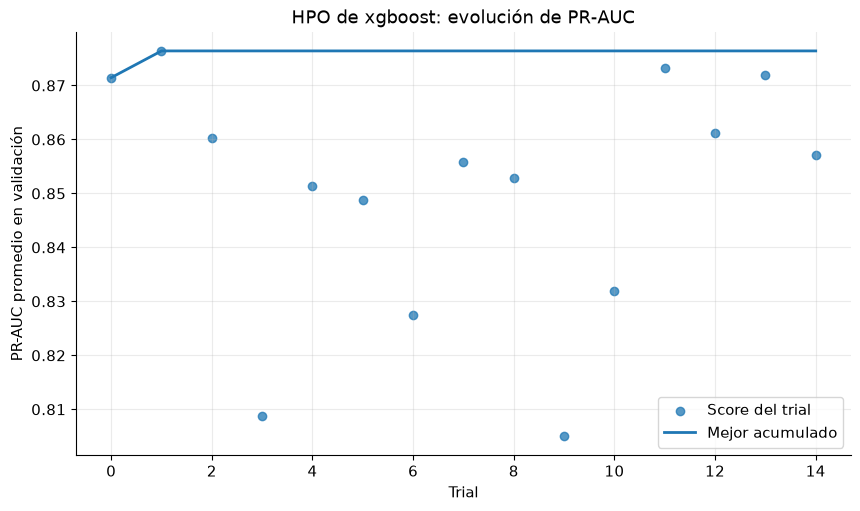

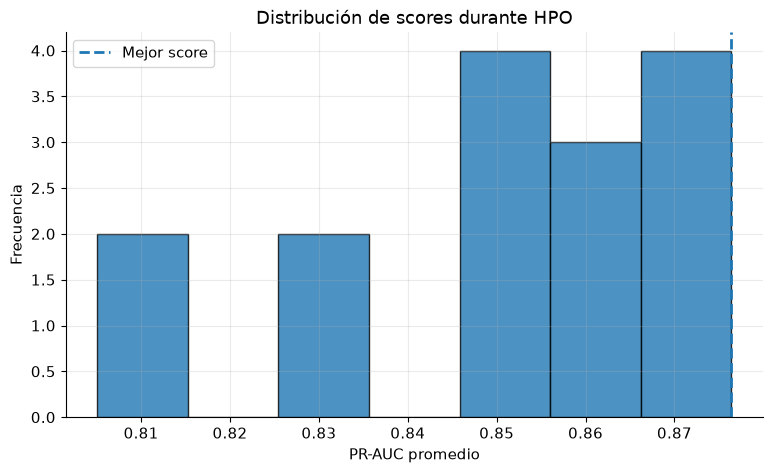

,parameter,importance
0,reg_lambda,0.614118
1,max_depth,0.109726
2,subsample,0.087756
3,colsample_bytree,0.052660
4,gamma,0.039488
5,reg_alpha,0.035577
6,learning_rate,0.026624
7,n_estimators,0.026451
8,min_child_weight,0.007600


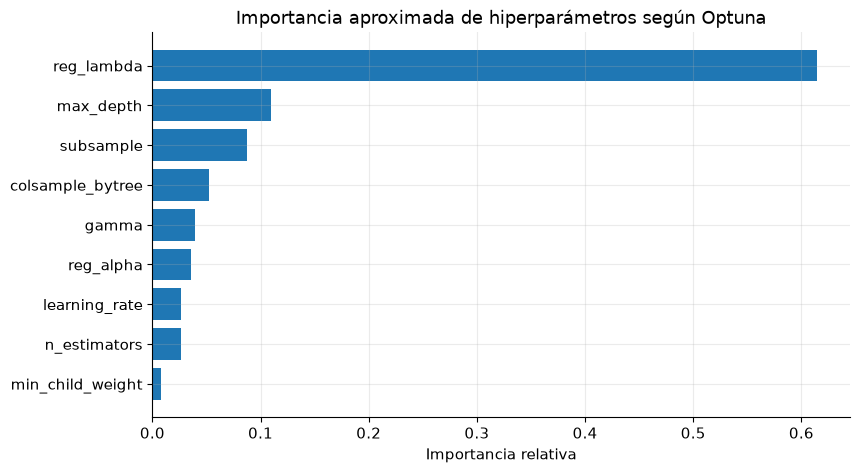

In [21]:
# =============================================================================
# 9.1 HPO diagnostics
# =============================================================================

def normalize_hpo_trials_report(trials_report: pd.DataFrame, used_fallback: bool) -> pd.DataFrame:
    """Normalize Optuna or RandomizedSearchCV reports to a common schema."""
    if trials_report.empty:
        raise ValueError("HPO trials report is empty.")
    normalized = trials_report.copy().reset_index(drop=True)
    if used_fallback:
        normalized["trial_number"] = np.arange(len(normalized))
        normalized["score"] = normalized["mean_test_score"]
        normalized["score_std"] = normalized.get("std_test_score", np.nan)
    else:
        normalized["trial_number"] = normalized["number"].astype(int)
        normalized["score"] = normalized["value"].astype(float)
        normalized["score_std"] = normalized.get("user_attrs_std_pr_auc", np.nan)
    ordered = normalized.sort_values("trial_number").copy()
    ordered["best_so_far"] = ordered["score"].cummax()
    return ordered


normalized_hpo_report = normalize_hpo_trials_report(hpo_trials_report, HPO_USED_FALLBACK)

display(normalized_hpo_report.head(10))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(normalized_hpo_report["trial_number"], normalized_hpo_report["score"], alpha=0.75, label="Score del trial")
ax.plot(normalized_hpo_report["trial_number"], normalized_hpo_report["best_so_far"], linewidth=2, label="Mejor acumulado")
ax.set_title(f"HPO de {HPO_FAMILY}: evolución de PR-AUC")
ax.set_xlabel("Trial")
ax.set_ylabel("PR-AUC promedio en validación")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(normalized_hpo_report["score"].dropna(), bins=min(20, max(5, len(normalized_hpo_report)//2)), edgecolor="black", alpha=0.8)
ax.axvline(normalized_hpo_report["score"].max(), linestyle="--", linewidth=2, label="Mejor score")
ax.set_title("Distribución de scores durante HPO")
ax.set_xlabel("PR-AUC promedio")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.show()

parameter_importance_df = pd.DataFrame()

if OPTUNA_AVAILABLE and not HPO_USED_FALLBACK and study is not None:
    try:
        from optuna.importance import get_param_importances
        importance = get_param_importances(study)
        parameter_importance_df = pd.DataFrame({
            "parameter": list(importance.keys()),
            "importance": list(importance.values()),
        }).sort_values("importance", ascending=False)
        display(parameter_importance_df)

        fig, ax = plt.subplots(figsize=(9, 5))
        plot_df = parameter_importance_df.sort_values("importance")
        ax.barh(plot_df["parameter"], plot_df["importance"])
        ax.set_title("Importancia aproximada de hiperparámetros según Optuna")
        ax.set_xlabel("Importancia relativa")
        plt.show()
    except Exception as exc:
        print(f"Could not compute Optuna parameter importances: {exc}")
else:
    print("Parameter importance via Optuna is not available in fallback mode.")

results_registry["normalized_hpo_report"] = normalized_hpo_report
results_registry["hpo_trials_report"] = hpo_trials_report


---
### 🧭 Guía docente — interpretación de hiperparámetros y modelo tuneado (celda 9.2)

- `interpret_hpo_parameter` es solo un diccionario de explicaciones en texto para la tabla.
- **Buen ejercicio en vivo:** mira los valores ganadores y pregunta "¿este modelo es más complejo o más conservador que el base?" (por ejemplo, `max_depth` alto + `learning_rate` alto = agresivo; `reg_lambda` alto + `min_child_weight` alto = conservador).
- Se construye `best_hpo_model` con los mejores hiperparámetros y el `scale_pos_weight` **del train completo** (no el de la muestra; son casi iguales).
- El modelo **no se entrena** aquí; solo se define. Se entrena dentro del CV de la siguiente sección.

In [22]:
# =============================================================================
# 9.2 Interpret HPO parameters and build tuned model
# =============================================================================

def interpret_hpo_parameter(parameter_name: str, value: Any) -> str:
    """Provide a short pedagogical interpretation of a hyperparameter."""
    if parameter_name == "learning_rate":
        return "Controla el tamaño de cada corrección agregada al ensemble."
    if parameter_name in {"n_estimators", "iterations"}:
        return "Controla cuántas correcciones secuenciales se acumulan."
    if parameter_name in {"max_depth", "depth"}:
        return "Controla la complejidad local de cada árbol."
    if parameter_name == "num_leaves":
        return "Controla la complejidad leaf-wise en LightGBM."
    if parameter_name in {"min_child_weight", "min_child_samples"}:
        return "Exige soporte mínimo para divisiones u hojas."
    if parameter_name == "gamma":
        return "Penaliza splits que no aportan suficiente ganancia."
    if parameter_name in {"reg_lambda", "reg_alpha", "l2_leaf_reg"}:
        return "Introduce regularización para reducir soluciones frágiles."
    if parameter_name == "subsample":
        return "Controla la fracción de filas usada por iteración."
    if parameter_name == "colsample_bytree":
        return "Controla la fracción de variables usada por árbol."
    if parameter_name in {"random_strength", "bagging_temperature", "subsample_freq"}:
        return "Controla aleatoriedad o regularización estocástica específica de la librería."
    return "Hiperparámetro específico de la familia seleccionada."


best_params_interpretation = pd.DataFrame([
    {"parameter": key, "value": value, "interpretation": interpret_hpo_parameter(key, value)}
    for key, value in best_hpo_params.items()
])

display(best_params_interpretation)

best_hpo_model = build_trial_model(
    family=HPO_FAMILY,
    params=best_hpo_params,
    scale_pos_weight_value=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs_model=N_JOBS_MODEL,
)

best_hpo_model_name = f"{HPO_FAMILY}_hpo_tuned"
model_registry[best_hpo_model_name] = best_hpo_model
print(best_hpo_model_name)
print(best_hpo_model)


,parameter,value,interpretation
0,n_estimators,504.000000,Controla cuántas correcciones secuenciales se ...
1,max_depth,2.000000,Controla la complejidad local de cada árbol.
2,learning_rate,0.182760,Controla el tamaño de cada corrección agregada...
3,subsample,0.941355,Controla la fracción de filas usada por iterac...
4,colsample_bytree,0.724319,Controla la fracción de variables usada por ár...
5,min_child_weight,3.000075,Exige soporte mínimo para divisiones u hojas.
6,gamma,0.917023,Penaliza splits que no aportan suficiente gana...
7,reg_lambda,0.501269,Introduce regularización para reducir solucion...
8,reg_alpha,0.029229,Introduce regularización para reducir solucion...


xgboost_hpo_tuned
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7243186887373967, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='aucpr', feature_types=None, feature_weights=None,
              gamma=0.9170225492671691, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.18276027831785724,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=3.0000746392781066, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=504,
              n_jobs=-1, num_parallel_tree=None, ...)


## 10. Modelo tuneado bajo CV común

El HPO pudo haberse hecho con menos folds o submuestra por razones docentes. Por eso, el modelo tuneado vuelve a competir bajo el CV común del notebook.


---
### 🧭 Guía docente — re-evaluación del modelo tuneado con el CV común (celda 10.1)

**Por qué es necesaria:** el HPO usó una submuestra y 3 folds, y su mejor score está inflado por el sesgo del ganador. Para comparar de forma justa con los modelos de la sección 7, el tuneado debe pasar **por el mismo CV de 5 folds sobre todo el train**.

**Resultados posibles y cómo interpretarlos:**
- **El tuneado mejora claramente (más que la desviación):** el HPO aportó.
- **Mejora marginalmente o empata:** muy común. Los defaults de las librerías modernas ya son buenos, y con 15 trials no se explora mucho. Buena lección: *el HPO no es magia*.
- **Empeora:** también pasa. El HPO sobreajustó al ruido de su submuestra / 3 folds.

**⚠️ Ojo, pregunta avanzada:** "¿Esta comparación es 100 % limpia?" No del todo: la submuestra del HPO está **contenida** en el train que usa el CV común, así que el modelo tuneado tiene una ligera ventaja (sus hiperparámetros se escogieron mirando parte de esos datos). La forma rigurosa es **nested cross-validation** (HPO dentro de cada fold externo), que es mucho más costosa. Para clase, basta con mencionarlo; el test final es la verificación independiente.

- El `drop_duplicates(subset=["model"], keep="last")` evita filas repetidas si la celda se ejecuta dos veces.


                           Evaluating tuned model: xgboost_hpo_tuned                            


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,relative_variability,fit_time_mean,score_time_mean,total_time_sec
0,boosting_tuned,xgboost_hpo_tuned,0.836951,0.014905,0.980829,0.011568,0.733108,0.043922,0.835054,0.041845,0.778981,0.011098,0.017809,2.523824,0.077026,13.070237


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,relative_variability,fit_time_mean,score_time_mean,total_time_sec
0,boosting_base,lightgbm_base_class_weight,0.855418,0.022684,0.980538,0.014057,0.865863,0.047522,0.827459,0.040391,0.844579,0.011709,0.026518,1.332861,0.194411,7.698688
1,boosting_tuned,xgboost_hpo_tuned,0.836951,0.014905,0.980829,0.011568,0.733108,0.043922,0.835054,0.041845,0.778981,0.011098,0.017809,2.523824,0.077026,13.070237
2,boosting_base,xgboost_base_class_weight,0.828156,0.028044,0.982153,0.011862,0.583069,0.043357,0.847744,0.042802,0.688951,0.019362,0.033863,1.766827,0.072706,9.249448
3,boosting_base,catboost_base_class_weight,0.791592,0.025223,0.979975,0.011780,0.551718,0.032261,0.855404,0.047640,0.669168,0.011309,0.031864,6.464217,0.044094,32.602343
4,baseline,logistic_class_weight_balanced,0.757136,0.058245,0.982484,0.011368,0.062795,0.004042,0.913762,0.025765,0.117468,0.006907,0.076929,0.417162,0.034686,2.293788
5,baseline,dummy_most_frequent,0.001729,0.000010,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005675,0.026622,0.020455,0.272675


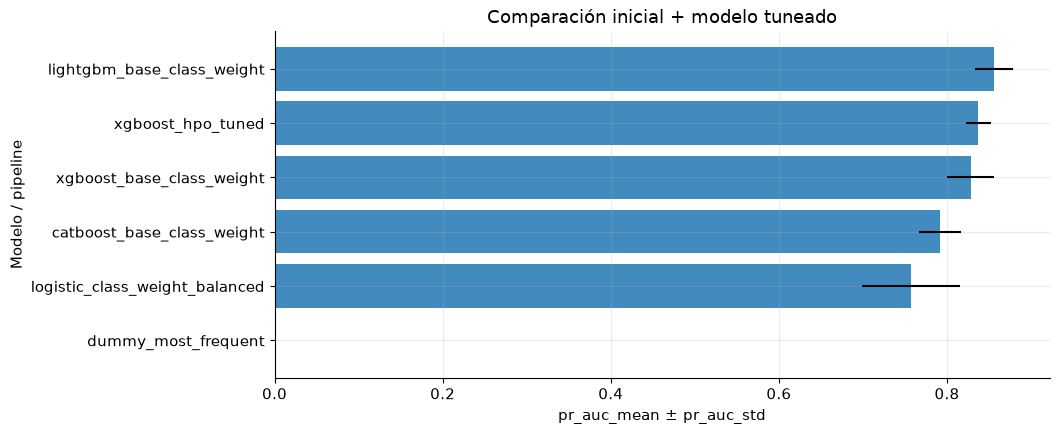

In [23]:
# =============================================================================
# 10.1 Evaluate tuned model under shared CV
# =============================================================================

print_section(f"Evaluating tuned model: {best_hpo_model_name}")

tuned_report = evaluate_model_cv(
    estimator=best_hpo_model,
    model_name=best_hpo_model_name,
    X_data=X_train,
    y_data=y_train,
    cv_strategy=cv,
    scoring=CLASSIFICATION_CV_SCORING,
    model_group="boosting_tuned",
    n_jobs=N_JOBS_OUTER,
)

tuned_report = add_stability_columns(tuned_report)

display(display_metric_columns(tuned_report))

comparison_with_tuned = combine_and_sort_results(
    [initial_comparison, tuned_report],
    "pr_auc_mean",
    ascending=False,
).drop_duplicates(subset=["model"], keep="last").reset_index(drop=True)
comparison_with_tuned = add_stability_columns(comparison_with_tuned)

display(display_metric_columns(comparison_with_tuned))

plot_cv_metric_comparison(
    comparison_with_tuned,
    "pr_auc_mean",
    "pr_auc_std",
    "Comparación inicial + modelo tuneado",
    top_n=10,
)

results_registry["tuned_report"] = tuned_report
results_registry["comparison_with_tuned"] = comparison_with_tuned


## 11. Estrategias de desbalance: none, class weights y SMOTE seguro

Comparamos tres hipótesis:

1. **Sin intervención adicional:** el modelo aprende sobre la distribución original.
2. **Class weights:** la clase positiva recibe mayor peso en la función de pérdida.
3. **SMOTE dentro del pipeline:** se generan ejemplos sintéticos solo dentro del bloque de entrenamiento de cada fold.

SMOTE nunca se aplica antes de cross-validation.


---
### 🧭 Guía docente — las tres estrategias de desbalance

| Estrategia | Qué hace | Efecto típico |
|---|---|---|
| **Sin intervención** | El modelo ve los datos tal cual | Probabilidades bien calibradas (bajas para fraude); con umbral 0.5 el recall suele ser bajo |
| **Class weights** | Cada error en un fraude cuesta ~577 veces más en la función de pérdida | Probabilidades **infladas**; con umbral 0.5 el recall sube y la precisión baja |
| **SMOTE** | Crea fraudes **sintéticos** interpolando entre un fraude y uno de sus k vecinos más cercanos (fraudes) | Más ejemplos positivos para aprender, a costa de datos artificiales que pueden no ser realistas |

**Idea clave:** pesos y SMOTE cambian sobre todo **la escala de las probabilidades** (y por lo tanto el umbral adecuado). Su efecto sobre el **ordenamiento** (que es lo que mide PR-AUC) puede ser pequeño, nulo o incluso negativo. Por eso **no es raro** que la estrategia "sin intervención" gane o empate en PR-AUC. Esto sorprende a los estudiantes y es una lección valiosa: *el desbalance no siempre se "arregla" con pesos o SMOTE; a menudo basta con una métrica adecuada y un buen umbral*.

**Por qué SMOTE debe ir dentro del pipeline:** si se aplica SMOTE **antes** del CV, los fraudes sintéticos se crean a partir de fraudes que luego caen en el fold de validación. El modelo "ve" versiones interpoladas de los datos con los que se le evalúa → score inflado (leakage). Dentro del pipeline de `imblearn`, SMOTE se ejecuta **solo en el bloque de entrenamiento de cada fold**, y nunca al predecir.

---
### 🧭 Guía docente — constructores de estrategias (celda 11.1)

Tres funciones constructoras:

- `build_model_without_extra_imbalance`: el modelo **sin** `scale_pos_weight`.
- `build_model_with_class_weights`: reutiliza `build_trial_model` (con pesos).
- `build_safe_smote_pipeline`: `StandardScaler → SMOTE → modelo` usando el **`Pipeline` de `imblearn`**, no el de sklearn. El de sklearn no sabe manejar pasos que cambian el número de filas (SMOTE agrega filas). El `Pipeline` de imblearn aplica SMOTE solo durante `fit`.
  - El `StandardScaler` está ahí **para SMOTE**, que usa distancias euclidianas (k vecinos); a XGBoost le es indiferente.
  - `sampling_strategy=0.10`: después de SMOTE, **fraudes = 10 % del número de normales** en el bloque de entrenamiento. En un fold (~182 000 normales, ~315 fraudes) eso significa pasar a ~18 200 fraudes, es decir, ~17 900 **sintéticos** (≈ 57 por cada fraude real). Buen número para discutir: "¿es razonable inventar 57 fraudes por cada uno real?".
  - El modelo dentro del pipeline de SMOTE va **sin** pesos (para no combinar ambas correcciones).

Se crean 5 candidatos: base sin intervención, base + pesos, tuneado + pesos, base + SMOTE, tuneado + SMOTE.

**⚠️ Ojo, candidatos duplicados:** `xgboost_tuned_class_weights` es **exactamente el mismo modelo** que `xgboost_hpo_tuned` de la sección 10, y `xgboost_base_class_weights` es idéntico a `xgboost_base_class_weight` de la sección 7. Por eso verás pares de filas con los mismos números en la tabla consolidada. No es un error de cálculo; son el mismo modelo con otro nombre. Si alguien lo nota, felicítalo 🙂.

La tabla `strategy_audit` solo documenta qué tiene cada candidato. Su columna `test_set_used=False` está **escrita a mano**; no es una verificación automática.

In [24]:
# =============================================================================
# 11.1 Imbalance strategy builders
# =============================================================================

def build_model_without_extra_imbalance(
    family: str,
    params: Optional[Dict[str, Any]] = None,
    random_state: int = RANDOM_STATE,
    n_jobs_model: int = N_JOBS_MODEL,
) -> Any:
    """Build a boosted model without class weights or resampling."""
    params = dict(params or get_default_hpo_params_for_family(family))

    if family == "xgboost":
        return XGBClassifier(
            **params,
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=random_state,
            n_jobs=n_jobs_model,
            tree_method="hist",
        )
    if family == "lightgbm":
        return LGBMClassifier(
            **params,
            objective="binary",
            random_state=random_state,
            n_jobs=n_jobs_model,
            verbosity=-1,
        )
    if family == "catboost":
        return CatBoostClassifier(
            **params,
            loss_function="Logloss",
            eval_metric="PRAUC",
            random_seed=random_state,
            verbose=False,
            allow_writing_files=False,
            thread_count=n_jobs_model,
        )
    raise ValueError(f"Unsupported family: {family}")


def build_model_with_class_weights(
    family: str,
    params: Optional[Dict[str, Any]] = None,
    scale_pos_weight_value: float = scale_pos_weight,
    random_state: int = RANDOM_STATE,
    n_jobs_model: int = N_JOBS_MODEL,
) -> Any:
    """Build a boosted model with class-weight logic."""
    return build_trial_model(
        family=family,
        params=dict(params or get_default_hpo_params_for_family(family)),
        scale_pos_weight_value=scale_pos_weight_value,
        random_state=random_state,
        n_jobs_model=n_jobs_model,
    )


def build_safe_smote_pipeline(
    family: str,
    params: Optional[Dict[str, Any]] = None,
    sampling_strategy: float = 0.10,
    random_state: int = RANDOM_STATE,
    n_jobs_model: int = N_JOBS_MODEL,
) -> Any:
    """Build StandardScaler -> SMOTE -> boosted model pipeline."""
    if not IMBLEARN_AVAILABLE or ImbPipeline is None or SMOTE is None:
        raise ImportError("imbalanced-learn is not available. Install it with pip install imbalanced-learn")

    model = build_model_without_extra_imbalance(
        family=family,
        params=params,
        random_state=random_state,
        n_jobs_model=n_jobs_model,
    )

    return ImbPipeline(steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(sampling_strategy=sampling_strategy, k_neighbors=5, random_state=random_state)),
        ("model", model),
    ])


base_params_for_strategy = get_default_hpo_params_for_family(HPO_FAMILY)
tuned_params_for_strategy = dict(best_hpo_params)

strategy_models: Dict[str, Any] = {}
strategy_models[f"{HPO_FAMILY}_base_no_extra_imbalance"] = build_model_without_extra_imbalance(HPO_FAMILY, base_params_for_strategy)
strategy_models[f"{HPO_FAMILY}_base_class_weights"] = build_model_with_class_weights(HPO_FAMILY, base_params_for_strategy, scale_pos_weight)
strategy_models[f"{HPO_FAMILY}_tuned_class_weights"] = build_model_with_class_weights(HPO_FAMILY, tuned_params_for_strategy, scale_pos_weight)

if IMBLEARN_AVAILABLE:
    strategy_models[f"{HPO_FAMILY}_base_smote_pipeline"] = build_safe_smote_pipeline(HPO_FAMILY, base_params_for_strategy, sampling_strategy=0.10)
    strategy_models[f"{HPO_FAMILY}_tuned_smote_pipeline"] = build_safe_smote_pipeline(HPO_FAMILY, tuned_params_for_strategy, sampling_strategy=0.10)
else:
    print("SMOTE strategies skipped because imbalanced-learn is unavailable.")

model_registry.update(strategy_models)

strategy_audit = pd.DataFrame([
    {
        "strategy": name,
        "uses_tuned_params": "tuned" in name,
        "uses_class_weight": "class_weights" in name,
        "uses_smote": "smote" in name,
        "test_set_used": False,
    }
    for name in strategy_models
])

display(strategy_audit)


,strategy,uses_tuned_params,uses_class_weight,uses_smote,test_set_used
0,xgboost_base_no_extra_imbalance,False,False,False,False
1,xgboost_base_class_weights,False,True,False,False
2,xgboost_tuned_class_weights,True,True,False,False
3,xgboost_base_smote_pipeline,False,False,True,False
4,xgboost_tuned_smote_pipeline,True,False,True,False


---
### 🧭 Guía docente — evaluación de estrategias (celda 11.2)

Otros 5 × 5 = 25 entrenamientos. Las variantes con SMOTE son las más lentas (entrenan con ~10 % más filas y el propio SMOTE busca vecinos).

**Qué discutir con la salida:**
- ¿Pesos vs sin intervención cambian mucho el **PR-AUC**? ¿Y el **recall a 0.5**? Normalmente el recall a 0.5 cambia mucho más que el PR-AUC → confirma que los pesos mueven sobre todo la escala de las probabilidades.
- ¿SMOTE justifica su costo? Si no gana claramente, la respuesta metodológica es **no conservarlo** (hipótesis rechazada).


                      Evaluating strategy: xgboost_base_no_extra_imbalance                      


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,score_time_mean,total_time_sec
0,imbalance_strategy,xgboost_base_no_extra_imbalance,0.848178,0.022666,0.983170,0.010884,0.941697,0.041086,0.781727,0.038369,0.853042,0.016432,1.726108,0.071285,9.054227



                        Evaluating strategy: xgboost_base_class_weights                         


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,score_time_mean,total_time_sec
0,imbalance_strategy,xgboost_base_class_weights,0.828156,0.028044,0.982153,0.011862,0.583069,0.043357,0.847744,0.042802,0.688951,0.019362,1.702417,0.073038,8.944750



                        Evaluating strategy: xgboost_tuned_class_weights                        


...


                        Evaluating strategy: xgboost_base_smote_pipeline                        


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,score_time_mean,total_time_sec
0,imbalance_strategy,xgboost_base_smote_pipeline,0.836928,0.020466,0.981201,0.011666,0.642900,0.054489,0.837553,0.039469,0.725680,0.032609,2.507547,0.124397,13.241566



                       Evaluating strategy: xgboost_tuned_smote_pipeline                        


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fit_time_mean,score_time_mean,total_time_sec
0,imbalance_strategy,xgboost_tuned_smote_pipeline,0.841559,0.019052,0.979405,0.009613,0.654391,0.058294,0.837553,0.031575,0.732405,0.025597,3.908680,0.139265,20.334836


,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,relative_variability,fit_time_mean,score_time_mean,total_time_sec
0,imbalance_strategy,xgboost_base_no_extra_imbalance,0.848178,0.022666,0.983170,0.010884,0.941697,0.041086,0.781727,0.038369,0.853042,0.016432,0.026723,1.726108,0.071285,9.054227
1,imbalance_strategy,xgboost_tuned_smote_pipeline,0.841559,0.019052,0.979405,0.009613,0.654391,0.058294,0.837553,0.031575,0.732405,0.025597,0.022639,3.908680,0.139265,20.334836
2,imbalance_strategy,xgboost_tuned_class_weights,0.836951,0.014905,0.980829,0.011568,0.733108,0.043922,0.835054,0.041845,0.778981,0.011098,0.017809,2.475451,0.077112,12.833512
3,imbalance_strategy,xgboost_base_smote_pipeline,0.836928,0.020466,0.981201,0.011666,0.642900,0.054489,0.837553,0.039469,0.725680,0.032609,0.024454,2.507547,0.124397,13.241566
4,imbalance_strategy,xgboost_base_class_weights,0.828156,0.028044,0.982153,0.011862,0.583069,0.043357,0.847744,0.042802,0.688951,0.019362,0.033863,1.702417,0.073038,8.944750


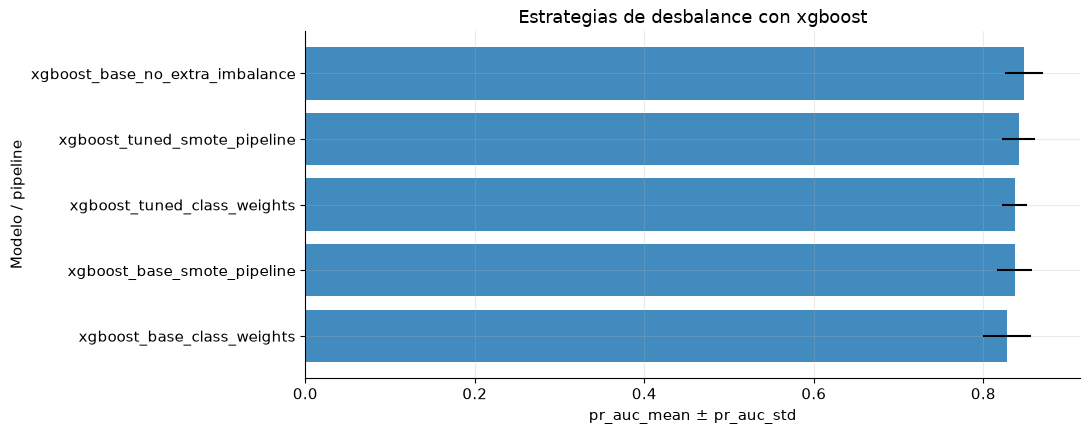

In [25]:
# =============================================================================
# 11.2 Evaluate imbalance strategies
# =============================================================================

strategy_reports = []

for name, estimator in strategy_models.items():
    print_section(f"Evaluating strategy: {name}")
    report = evaluate_model_cv(
        estimator=estimator,
        model_name=name,
        X_data=X_train,
        y_data=y_train,
        cv_strategy=cv,
        scoring=CLASSIFICATION_CV_SCORING,
        model_group="imbalance_strategy",
        n_jobs=N_JOBS_OUTER,
    )
    strategy_reports.append(report)
    display(display_metric_columns(report))

strategy_results = combine_and_sort_results(strategy_reports, "pr_auc_mean", ascending=False)
strategy_results = add_stability_columns(strategy_results)

results_registry["strategy_results"] = strategy_results

display(display_metric_columns(strategy_results))

plot_cv_metric_comparison(
    strategy_results,
    "pr_auc_mean",
    "pr_auc_std",
    f"Estrategias de desbalance con {HPO_FAMILY}",
)


## 12. Selección provisional por CV

La selección provisional usa únicamente evidencia de validación cruzada. El test set sigue intacto.


---
### 🧭 Guía docente — selección provisional del candidato (celda 12.1)

Se juntan **todas** las tablas (baselines, boosting base, tuneado, estrategias), se ordenan por `pr_auc_mean` y **se elige la primera fila**.

**⚠️ Ojo, tensión con el contrato de la sección 1:** el contrato dice que "no se declara ganador solo por el mejor promedio", pero el código escoge exactamente por el mejor promedio (`iloc[0]`). Es una simplificación. En clase conviene hacer la selección "en voz alta":

1. ¿La diferencia entre el 1.º y el 2.º es mayor que sus desviaciones? Si no, es un empate.
2. Si hay empate, **regla de parsimonia** (o regla de "una desviación estándar"): preferir el modelo más simple o más barato cuyo score esté a menos de una desviación del mejor.
3. Revisar `fit_time_mean`: ¿el ganador es mucho más lento?

Se elige **una combinación completa** (familia + hiperparámetros + estrategia de desbalance), no solo un algoritmo. `candidate_model` es un objeto **sin entrenar** tomado de `model_registry`.

**Pregunta posible:** "Ganó el modelo sin pesos, ¿eso no contradice todo lo del desbalance?" No: PR-AUC mide ordenamiento, y un modelo sin pesos puede ordenar igual o mejor. El desbalance se maneja con la **métrica** y el **umbral** (siguiente sección).

Además, escoger el máximo entre ~10 candidatos también tiene un sesgo del ganador (como en el HPO). El test final lo verifica.

,model_group,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,relative_variability,fit_time_mean,score_time_mean,total_time_sec
0,boosting_base,lightgbm_base_class_weight,0.855418,0.022684,0.980538,0.014057,0.865863,0.047522,0.827459,0.040391,0.844579,0.011709,0.026518,1.332861,0.194411,7.698688
1,imbalance_strategy,xgboost_base_no_extra_imbalance,0.848178,0.022666,0.983170,0.010884,0.941697,0.041086,0.781727,0.038369,0.853042,0.016432,0.026723,1.726108,0.071285,9.054227
2,imbalance_strategy,xgboost_tuned_smote_pipeline,0.841559,0.019052,0.979405,0.009613,0.654391,0.058294,0.837553,0.031575,0.732405,0.025597,0.022639,3.908680,0.139265,20.334836
3,imbalance_strategy,xgboost_tuned_class_weights,0.836951,0.014905,0.980829,0.011568,0.733108,0.043922,0.835054,0.041845,0.778981,0.011098,0.017809,2.475451,0.077112,12.833512
4,boosting_tuned,xgboost_hpo_tuned,0.836951,0.014905,0.980829,0.011568,0.733108,0.043922,0.835054,0.041845,0.778981,0.011098,0.017809,2.523824,0.077026,13.070237
5,imbalance_strategy,xgboost_base_smote_pipeline,0.836928,0.020466,0.981201,0.011666,0.642900,0.054489,0.837553,0.039469,0.725680,0.032609,0.024454,2.507547,0.124397,13.241566
6,boosting_base,xgboost_base_class_weight,0.828156,0.028044,0.982153,0.011862,0.583069,0.043357,0.847744,0.042802,0.688951,0.019362,0.033863,1.766827,0.072706,9.249448
7,imbalance_strategy,xgboost_base_class_weights,0.828156,0.028044,0.982153,0.011862,0.583069,0.043357,0.847744,0.042802,0.688951,0.019362,0.033863,1.702417,0.073038,8.944750
8,boosting_base,catboost_base_class_weight,0.791592,0.025223,0.979975,0.011780,0.551718,0.032261,0.855404,0.047640,0.669168,0.011309,0.031864,6.464217,0.044094,32.602343
9,baseline,logistic_class_weight_balanced,0.757136,0.058245,0.982484,0.011368,0.062795,0.004042,0.913762,0.025765,0.117468,0.006907,0.076929,0.417162,0.034686,2.293788


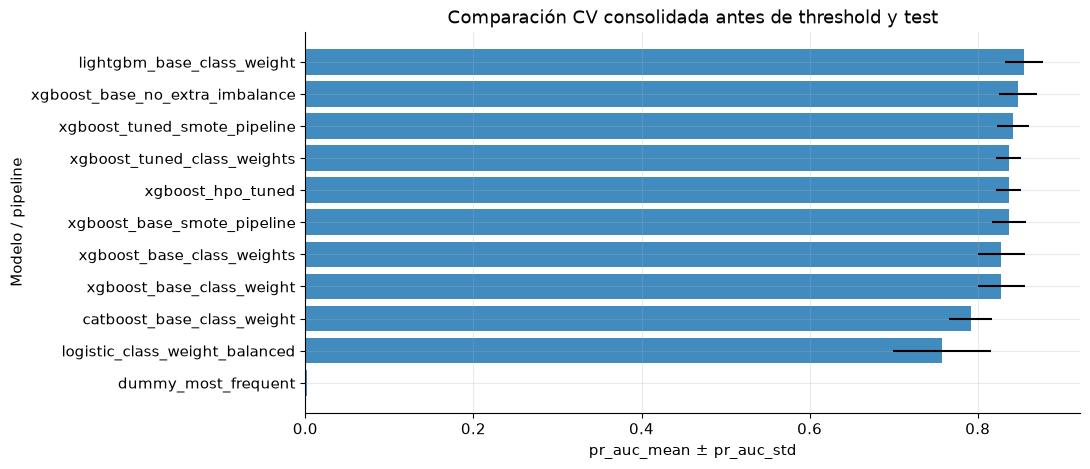

,candidate_model,candidate_group,cv_pr_auc_mean,cv_pr_auc_std,test_set_used
0,lightgbm_base_class_weight,boosting_base,0.855418,0.022684,False


LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
               learning_rate=0.05, min_child_samples=40, n_estimators=250,
               n_jobs=-1, objective='binary', random_state=42, reg_lambda=1.0,
               subsample=0.9, subsample_freq=1, verbosity=-1)


In [26]:
# =============================================================================
# 12.1 Consolidated CV comparison and candidate selection
# =============================================================================

final_cv_comparison = combine_and_sort_results(
    [baseline_results, boosting_base_results, tuned_report, strategy_results],
    sort_metric="pr_auc_mean",
    ascending=False,
).drop_duplicates(subset=["model"], keep="last").reset_index(drop=True)

final_cv_comparison = add_stability_columns(final_cv_comparison)
results_registry["final_cv_comparison"] = final_cv_comparison

display(display_metric_columns(final_cv_comparison))

plot_cv_metric_comparison(
    final_cv_comparison,
    "pr_auc_mean",
    "pr_auc_std",
    "Comparación CV consolidada antes de threshold y test",
    top_n=12,
)

candidate_cv_row = final_cv_comparison.iloc[0]
CANDIDATE_MODEL_NAME = str(candidate_cv_row["model"])
CANDIDATE_MODEL_GROUP = str(candidate_cv_row["model_group"])
CANDIDATE_PR_AUC_MEAN = float(candidate_cv_row["pr_auc_mean"])
CANDIDATE_PR_AUC_STD = float(candidate_cv_row["pr_auc_std"])

if CANDIDATE_MODEL_NAME not in model_registry:
    raise ValueError(f"Candidate model '{CANDIDATE_MODEL_NAME}' not found in model_registry.")

candidate_model = model_registry[CANDIDATE_MODEL_NAME]

candidate_selection_summary = pd.DataFrame([{
    "candidate_model": CANDIDATE_MODEL_NAME,
    "candidate_group": CANDIDATE_MODEL_GROUP,
    "cv_pr_auc_mean": CANDIDATE_PR_AUC_MEAN,
    "cv_pr_auc_std": CANDIDATE_PR_AUC_STD,
    "test_set_used": False,
}])

display(candidate_selection_summary)
print(candidate_model)


## 13. Out-of-fold scores y threshold policy

El candidato produce scores. El threshold convierte scores en decisiones.

Usaremos out-of-fold predictions sobre training para seleccionar una política sin tocar test.


---
### 🧭 Guía docente — qué son las predicciones out-of-fold (OOF)

**Idea:** con 5 folds, cada fila del train está exactamente una vez en un fold de validación. Si guardamos la predicción que hizo el modelo **que no vio esa fila**, obtenemos un score "honesto" para **todas** las filas del train. Eso es `cross_val_predict`.

```
Fold 1: entrena con 2,3,4,5 → predice el fold 1
Fold 2: entrena con 1,3,4,5 → predice el fold 2
...
Resultado: 1 score honesto por cada fila del train
```

**¿Para qué?** Para escoger el umbral **sin tocar el test**. Si escogiéramos el umbral con predicciones sobre datos de entrenamiento (vistos por el modelo), serían demasiado optimistas; si lo escogiéramos en el test, contaminaríamos el test.

**Umbral vs modelo:** el modelo produce un *score* (≈ probabilidad). El *umbral* convierte ese score en una decisión (alertar / no alertar). Son dos decisiones distintas: una técnica (el ordenamiento) y una de **negocio** (cuántas alertas podemos revisar, cuánto cuesta un fraude no detectado).

---
### 🧭 Guía docente — scores OOF y curvas (celda 13.1)

- `get_out_of_fold_scores`: `cross_val_predict(..., method="predict_proba")` y toma la columna 1 (probabilidad de fraude). Si el modelo no tiene `predict_proba`, usa `decision_function` y la reescala a [0, 1] (aquí no ocurre; todos los boosted tienen `predict_proba`).
- `OOF_PR_AUC` se calcula sobre **todas** las filas juntas. Por eso puede diferir un poco de `CANDIDATE_PR_AUC_MEAN` (que es el **promedio** de 5 PR-AUC por fold). Ambos son válidos; no es un error.

**Los tres gráficos:**

1. **Curva Precision–Recall**: cada punto es un umbral. La línea punteada horizontal es la **prevalencia** = desempeño del azar. El área bajo la curva ≈ PR-AUC. Muestra el costo de subir el recall: a partir de cierto punto la precisión se desploma.
2. **Curva ROC**: casi pegada a la esquina superior izquierda (AUC > 0.95). Úsala para mostrar que **se ve excelente aunque la precisión real pueda ser baja** (ver la celda añadida de la sección 4).
3. **Histograma de scores por clase (escala log)**: la mayoría de los normales tienen score ≈ 0 y muchos fraudes tienen score alto. La zona donde se superponen es donde vive la dificultad; el umbral decide en qué parte de esa zona se corta.

**⚠️ Ojo:** si el candidato usa pesos o SMOTE, los scores de fraude se van a la derecha (probabilidades infladas). Si no los usa, muchos fraudes pueden tener scores bajos (0.05–0.3). Esto determina dónde caerá el mejor umbral.


                      OOF SCORES FOR CANDIDATE: lightgbm_base_class_weight                      


,candidate_model,n_oof_scores,min_score,median_score,max_score,oof_pr_auc,oof_roc_auc,test_set_used
0,lightgbm_base_class_weight,227845,0.000002,0.000026,0.999980,0.854294,0.979145,False


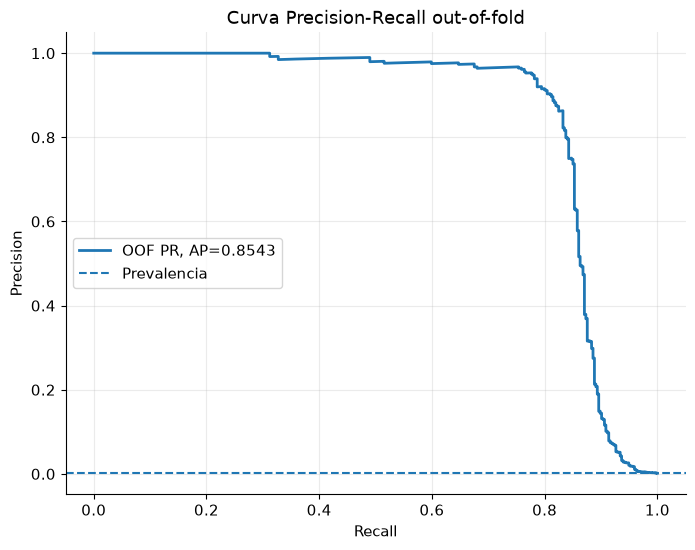

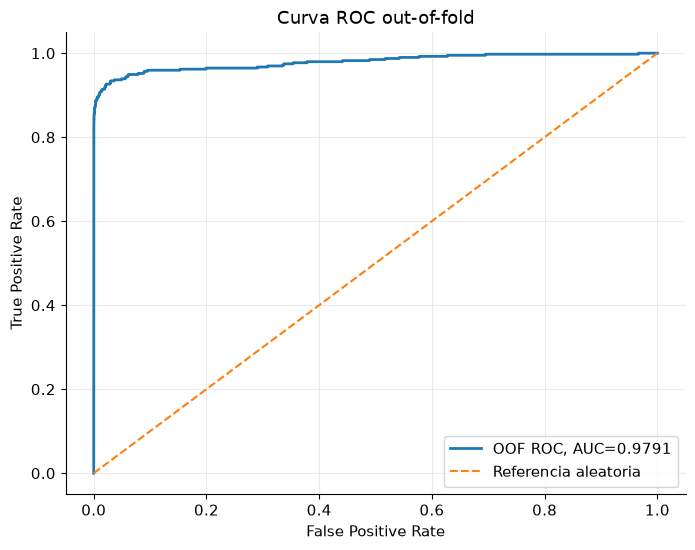

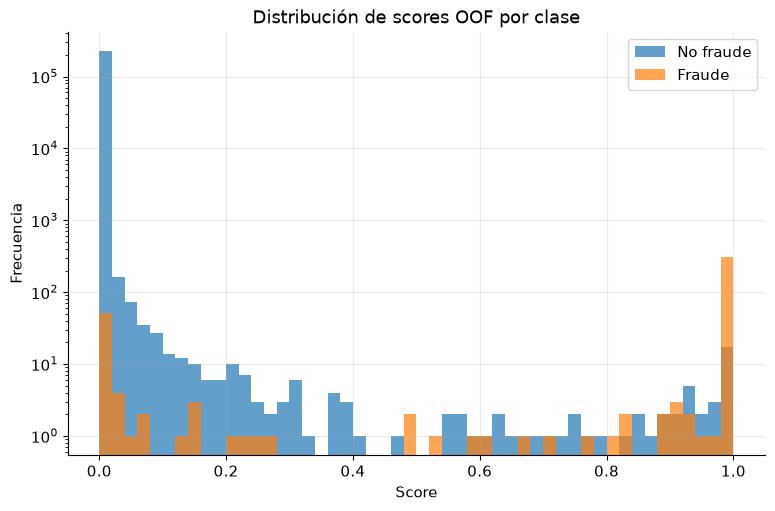

In [27]:
# =============================================================================
# 13.1 OOF scores and curves
# =============================================================================

def get_out_of_fold_scores(
    estimator: Any,
    X_data: pd.DataFrame,
    y_data: pd.Series,
    cv_strategy: StratifiedKFold,
    n_jobs: int = N_JOBS_OUTER,
) -> np.ndarray:
    """Generate out-of-fold positive-class scores."""
    try:
        proba = cross_val_predict(
            estimator=estimator,
            X=X_data,
            y=y_data,
            cv=cv_strategy,
            method="predict_proba",
            n_jobs=n_jobs,
        )
        scores = proba[:, 1]
    except Exception as proba_exc:
        print(f"predict_proba failed, using decision_function. Reason: {proba_exc}")
        raw_scores = cross_val_predict(
            estimator=estimator,
            X=X_data,
            y=y_data,
            cv=cv_strategy,
            method="decision_function",
            n_jobs=n_jobs,
        )
        raw_scores = np.asarray(raw_scores, dtype=float)
        scores = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
    scores = np.asarray(scores, dtype=float)
    if np.isnan(scores).any():
        raise ValueError("OOF scores contain NaN values.")
    return scores


print_section(f"OOF SCORES FOR CANDIDATE: {CANDIDATE_MODEL_NAME}")
oof_scores = get_out_of_fold_scores(candidate_model, X_train, y_train, cv, n_jobs=N_JOBS_OUTER)

OOF_PR_AUC = float(average_precision_score(y_train, oof_scores))
OOF_ROC_AUC = float(roc_auc_score(y_train, oof_scores))

oof_score_summary = pd.DataFrame([{
    "candidate_model": CANDIDATE_MODEL_NAME,
    "n_oof_scores": len(oof_scores),
    "min_score": float(np.min(oof_scores)),
    "median_score": float(np.median(oof_scores)),
    "max_score": float(np.max(oof_scores)),
    "oof_pr_auc": OOF_PR_AUC,
    "oof_roc_auc": OOF_ROC_AUC,
    "test_set_used": False,
}])

display(oof_score_summary)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_train, oof_scores)
fpr_curve, tpr_curve, roc_thresholds = roc_curve(y_train, oof_scores)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_curve, precision_curve, linewidth=2, label=f"OOF PR, AP={OOF_PR_AUC:.4f}")
ax.axhline(float(y_train.mean()), linestyle="--", linewidth=1.5, label="Prevalencia")
ax.set_title("Curva Precision-Recall out-of-fold")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_curve, tpr_curve, linewidth=2, label=f"OOF ROC, AUC={OOF_ROC_AUC:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Referencia aleatoria")
ax.set_title("Curva ROC out-of-fold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

score_df = pd.DataFrame({"true_label": y_train.values, "score": oof_scores})
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(score_df.query("true_label == 0")["score"], bins=50, alpha=0.70, label="No fraude")
ax.hist(score_df.query("true_label == 1")["score"], bins=50, alpha=0.70, label="Fraude")
ax.set_yscale("log")
ax.set_title("Distribución de scores OOF por clase")
ax.set_xlabel("Score")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.show()


---
### 🧭 Guía docente — barrido de umbrales y política (celda 13.2)

- `compute_binary_policy_metrics`: para un umbral, calcula precision, recall, F1, la matriz de confusión (TN, FP, FN, TP) y cuántas alertas genera.
- `threshold_grid`: ≈ 190 umbrales, **más densos cerca de 0** (entre 0.001 y 0.05 hay 50), porque con desbalance los umbrales útiles pueden ser muy pequeños.
- `select_threshold_by_policy`: tres políticas posibles:

| Política | Pregunta de negocio que responde |
|---|---|
| `max_f1` (la usada) | "Quiero un balance entre precisión y recall" (neutra, académica) |
| `max_precision_with_recall_floor` | "Debo detectar al menos el 80 % de los fraudes; entre los umbrales que lo logran, dame el que menos falsas alarmas genera" |
| `max_recall_with_alert_cap` | "Mi equipo puede revisar como máximo el 2 % de las transacciones; detecta el máximo de fraudes con esa capacidad" |

**Mensaje clave:** el umbral **no es 0.5 por defecto**; es una **política** que se decide con criterios de negocio y se estima con OOF.

**Qué mirar en la salida:**
- El gráfico precision/recall/F1 vs umbral: recall baja al subir el umbral, precisión sube. El F1 tiene un máximo.
- El gráfico de volumen de alertas: traduce el umbral a **carga de trabajo** (algo que el negocio entiende).
- La tabla `threshold_policy_comparison`: umbral 0.5 vs el elegido. Si el candidato no usa pesos, el umbral elegido suele ser **menor que 0.5**; si usa pesos, suele ser **mayor**.
- `pretest_decision_record`: la "foto" de todas las decisiones **antes** de mirar el test. Es la evidencia de que no se hizo trampa.

,threshold,precision,recall,f1,tn,fp,fn,tp,predicted_positive_count,predicted_positive_rate
187,0.980000,0.947692,0.781726,0.856745,227434,17,86,308,325,0.001426
184,0.950000,0.939394,0.786802,0.856354,227431,20,84,310,330,0.001448
185,0.960000,0.939210,0.784264,0.854772,227431,20,85,309,329,0.001444
169,0.800000,0.901408,0.812183,0.854473,227416,35,74,320,355,0.001558
170,0.810000,0.901408,0.812183,0.854473,227416,35,74,320,355,0.001558
176,0.870000,0.910920,0.804569,0.854447,227420,31,77,317,348,0.001527
177,0.880000,0.910920,0.804569,0.854447,227420,31,77,317,348,0.001527
186,0.970000,0.941896,0.781726,0.854369,227432,19,86,308,327,0.001435
183,0.940000,0.933735,0.786802,0.853994,227429,22,84,310,332,0.001457
164,0.750000,0.896648,0.814721,0.853723,227414,37,73,321,358,0.001571


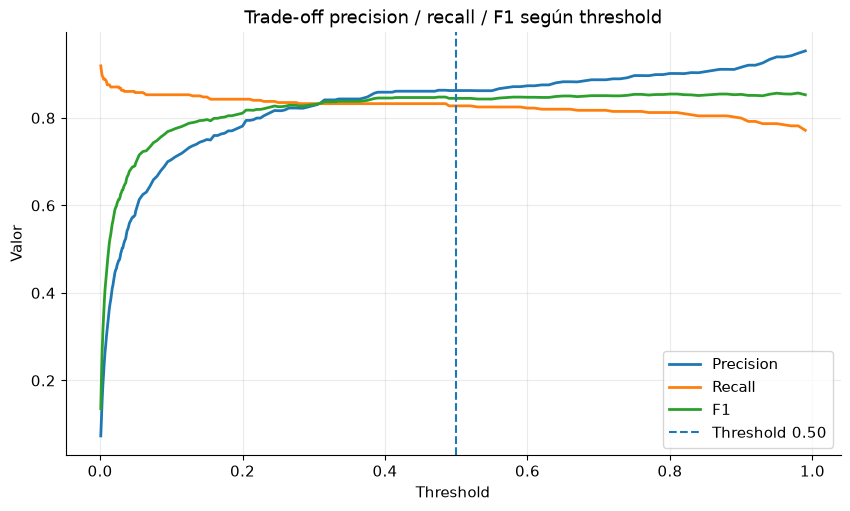

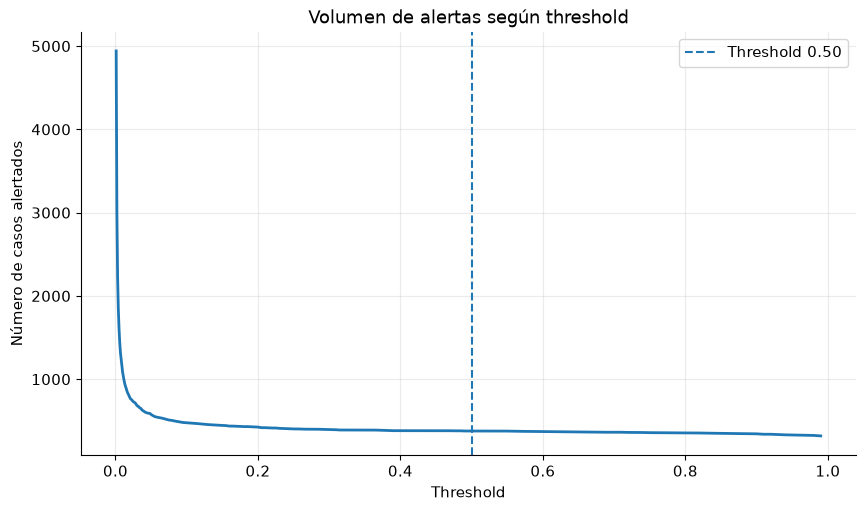

,policy,threshold,precision,recall,f1,tn,fp,fn,tp,predicted_positive_count,predicted_positive_rate
0,default_0.50,0.500000,0.862434,0.827411,0.844560,227399,52,68,326,378,0.001659
1,max_f1,0.980000,0.947692,0.781726,0.856745,227434,17,86,308,325,0.001426


,candidate_model,cv_pr_auc_mean,cv_pr_auc_std,oof_pr_auc,oof_roc_auc,threshold_policy,selected_threshold,oof_precision,oof_recall,oof_f1,test_set_used
0,lightgbm_base_class_weight,0.855418,0.022684,0.854294,0.979145,max_f1,0.980000,0.947692,0.781726,0.856745,False


In [28]:
# =============================================================================
# 13.2 Threshold sweep and policy
# =============================================================================

def compute_binary_policy_metrics(y_true: pd.Series, scores: np.ndarray, threshold: float) -> Dict[str, Any]:
    """Compute threshold-level binary metrics."""
    y_pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[NEGATIVE_LABEL, POSITIVE_LABEL]).ravel()
    return {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "predicted_positive_count": int(y_pred.sum()),
        "predicted_positive_rate": float(y_pred.mean()),
    }


def build_threshold_sweep_table(y_true: pd.Series, scores: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    """Build threshold sweep table."""
    return pd.DataFrame([
        compute_binary_policy_metrics(y_true, scores, float(threshold))
        for threshold in thresholds
    ])


def select_threshold_by_policy(
    threshold_table: pd.DataFrame,
    policy: str = "max_f1",
    target_recall_floor: float = 0.80,
    max_alert_rate: float = 0.02,
) -> pd.Series:
    """Select threshold by explicit policy."""
    require_columns(threshold_table, ["threshold", "precision", "recall", "f1", "predicted_positive_rate"], "threshold_table")
    if policy == "max_f1":
        return threshold_table.sort_values(["f1", "recall", "precision"], ascending=[False, False, False]).iloc[0]
    if policy == "max_precision_with_recall_floor":
        candidates = threshold_table[threshold_table["recall"] >= target_recall_floor]
        if candidates.empty:
            raise ValueError("No threshold satisfies recall floor.")
        return candidates.sort_values(["precision", "f1", "threshold"], ascending=[False, False, False]).iloc[0]
    if policy == "max_recall_with_alert_cap":
        candidates = threshold_table[threshold_table["predicted_positive_rate"] <= max_alert_rate]
        if candidates.empty:
            raise ValueError("No threshold satisfies alert-rate cap.")
        return candidates.sort_values(["recall", "precision", "f1"], ascending=[False, False, False]).iloc[0]
    raise ValueError(f"Unsupported policy: {policy}")


threshold_grid = np.unique(np.concatenate([
    np.linspace(0.001, 0.050, 50),
    np.linspace(0.055, 0.500, 90),
    np.linspace(0.510, 0.990, 49),
]))

threshold_sweep_df = build_threshold_sweep_table(y_train, oof_scores, threshold_grid)

display(threshold_sweep_df.sort_values("f1", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["precision"], linewidth=2, label="Precision")
ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["recall"], linewidth=2, label="Recall")
ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["f1"], linewidth=2, label="F1")
ax.axvline(0.50, linestyle="--", linewidth=1.5, label="Threshold 0.50")
ax.set_title("Trade-off precision / recall / F1 según threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Valor")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(threshold_sweep_df["threshold"], threshold_sweep_df["predicted_positive_count"], linewidth=2)
ax.axvline(0.50, linestyle="--", linewidth=1.5, label="Threshold 0.50")
ax.set_title("Volumen de alertas según threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Número de casos alertados")
ax.legend()
plt.show()

THRESHOLD_POLICY = "max_f1"
TARGET_RECALL_FLOOR = 0.80
MAX_ALERT_RATE = 0.02

selected_threshold_row = select_threshold_by_policy(
    threshold_table=threshold_sweep_df,
    policy=THRESHOLD_POLICY,
    target_recall_floor=TARGET_RECALL_FLOOR,
    max_alert_rate=MAX_ALERT_RATE,
)

SELECTED_THRESHOLD = float(selected_threshold_row["threshold"])
selected_threshold_metrics = compute_binary_policy_metrics(y_train, oof_scores, SELECTED_THRESHOLD)
default_threshold_metrics = compute_binary_policy_metrics(y_train, oof_scores, 0.50)

threshold_policy_comparison = pd.DataFrame([
    {"policy": "default_0.50", **default_threshold_metrics},
    {"policy": THRESHOLD_POLICY, **selected_threshold_metrics},
])

display(threshold_policy_comparison)

pretest_decision_record = pd.DataFrame([{
    "candidate_model": CANDIDATE_MODEL_NAME,
    "cv_pr_auc_mean": CANDIDATE_PR_AUC_MEAN,
    "cv_pr_auc_std": CANDIDATE_PR_AUC_STD,
    "oof_pr_auc": OOF_PR_AUC,
    "oof_roc_auc": OOF_ROC_AUC,
    "threshold_policy": THRESHOLD_POLICY,
    "selected_threshold": SELECTED_THRESHOLD,
    "oof_precision": selected_threshold_metrics["precision"],
    "oof_recall": selected_threshold_metrics["recall"],
    "oof_f1": selected_threshold_metrics["f1"],
    "test_set_used": False,
}])

display(pretest_decision_record)

results_registry["threshold_sweep_df"] = threshold_sweep_df
results_registry["threshold_policy_comparison"] = threshold_policy_comparison
results_registry["pretest_decision_record"] = pretest_decision_record


## 14. Evaluación final en test reservado

El test set se usa una sola vez, después de congelar:

- candidato;
- métrica principal;
- estrategia de desbalance;
- HPO;
- threshold.

No se recalcula threshold en test.


---
### 🧭 Guía docente — el momento del test

Todo lo que se decidió antes queda **congelado**. Frase para la clase: *"Ahora sí abrimos el sobre del examen final. Lo que salga, sale; no podemos volver a cambiar nada."*

Si después de ver el test se cambia el modelo o el umbral y se vuelve a evaluar, el test se convierte en un segundo conjunto de validación, y ya no tenemos una estimación honesta.

---
### 🧭 Guía docente — entrenamiento final y scores de test (celda 14.1)

- `clone(candidate_model)`: copia **sin entrenar** con los mismos hiperparámetros (buena práctica para no arrastrar estados de entrenamientos previos).
- `final_model.fit(X_train, y_train)`: se entrena **una vez** con **todo** el train (el 80 %). Tiene más datos que cualquiera de los modelos de CV, por eso puede rendir un poco mejor.
- `get_positive_class_scores_from_fitted_model`: igual que en OOF, pero con el modelo ya entrenado.
- Se calculan `TEST_PR_AUC` y `TEST_ROC_AUC`. **Compáralos con el CV y el OOF**: si están en un rango parecido (dentro de la variabilidad observada entre folds), el proceso fue consistente. Si el test es mucho peor, hay que sospechar de sobreajuste en la selección o de un cambio en los datos.
- Recuerda: ≈ 98 fraudes en test → el PR-AUC de test también tiene su incertidumbre.

In [29]:
# =============================================================================
# 14.1 Final fit and test scores
# =============================================================================

print_section("FINAL MODEL FIT")

final_model = clone(candidate_model)
final_fit_start_time = time.time()
final_model.fit(X_train, y_train)
final_fit_time_sec = time.time() - final_fit_start_time

print(f"Final candidate model: {CANDIDATE_MODEL_NAME}")
print(f"Final fit time: {final_fit_time_sec:.2f} seconds")


def get_positive_class_scores_from_fitted_model(fitted_estimator: Any, X_data: pd.DataFrame) -> np.ndarray:
    """Extract positive-class scores from a fitted classifier."""
    if hasattr(fitted_estimator, "predict_proba"):
        proba = fitted_estimator.predict_proba(X_data)
        if proba.ndim != 2 or proba.shape[1] < 2:
            raise ValueError("predict_proba did not return a two-column matrix.")
        scores = proba[:, 1]
    elif hasattr(fitted_estimator, "decision_function"):
        raw_scores = np.asarray(fitted_estimator.decision_function(X_data), dtype=float)
        scores = (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min())
    else:
        raise AttributeError("Estimator has neither predict_proba nor decision_function.")
    scores = np.asarray(scores, dtype=float)
    if np.isnan(scores).any():
        raise ValueError("Extracted scores contain NaN values.")
    return scores


y_test_scores = get_positive_class_scores_from_fitted_model(final_model, X_test)

TEST_PR_AUC = float(average_precision_score(y_test, y_test_scores))
TEST_ROC_AUC = float(roc_auc_score(y_test, y_test_scores))

test_ranking_summary = pd.DataFrame([{
    "candidate_model": CANDIDATE_MODEL_NAME,
    "test_pr_auc": TEST_PR_AUC,
    "test_roc_auc": TEST_ROC_AUC,
    "selected_threshold": SELECTED_THRESHOLD,
    "threshold_policy": THRESHOLD_POLICY,
    "test_set_used_for_selection": False,
}])

display(test_ranking_summary)



                                        FINAL MODEL FIT                                         
Final candidate model: lightgbm_base_class_weight
Final fit time: 1.63 seconds


,candidate_model,test_pr_auc,test_roc_auc,selected_threshold,threshold_policy,test_set_used_for_selection
0,lightgbm_base_class_weight,0.880180,0.978573,0.980000,max_f1,False


---
### 🧭 Guía docente — curvas de test y matriz de confusión (celda 14.2)

- Se aplica el umbral **elegido con OOF**, sin recalcularlo en test.
- Se compara con el umbral 0.5 **solo como referencia** (no para escoger).

**Cómo leer la matriz de confusión con el negocio en mente:**

|  | Predice no fraude | Predice fraude |
|---|---|---|
| **Es no fraude** | TN: todo bien | **FP: falsa alarma** (costo: revisión, cliente molesto) |
| **Es fraude** | **FN: fraude no detectado** (costo: dinero perdido) | TP: fraude atrapado |

Ejercicio en vivo: "Si revisar una alerta cuesta 5 USD y un fraude no detectado cuesta 200 USD en promedio, ¿cuánto cuesta este umbral?" Así se conecta el umbral con una función de costo.

- `classification_report`: precision/recall/F1 por clase. Las métricas de la clase `no_fraud` son ≈ 1.0 y **no dicen nada**; mira la fila `fraud`. Ignora la línea `accuracy`.

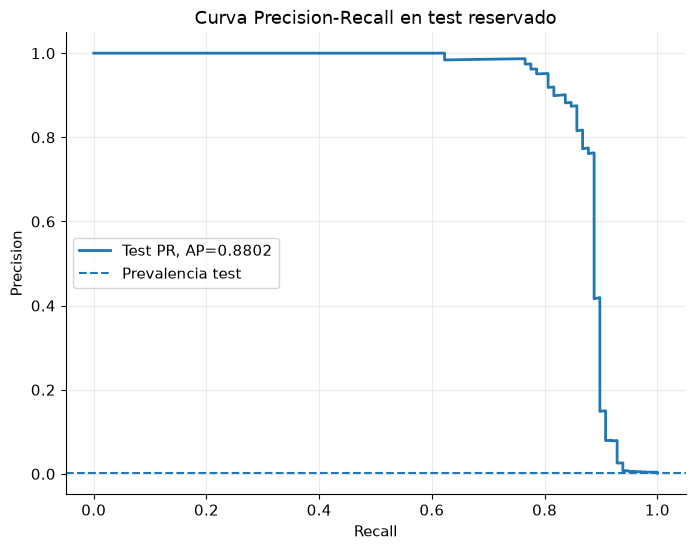

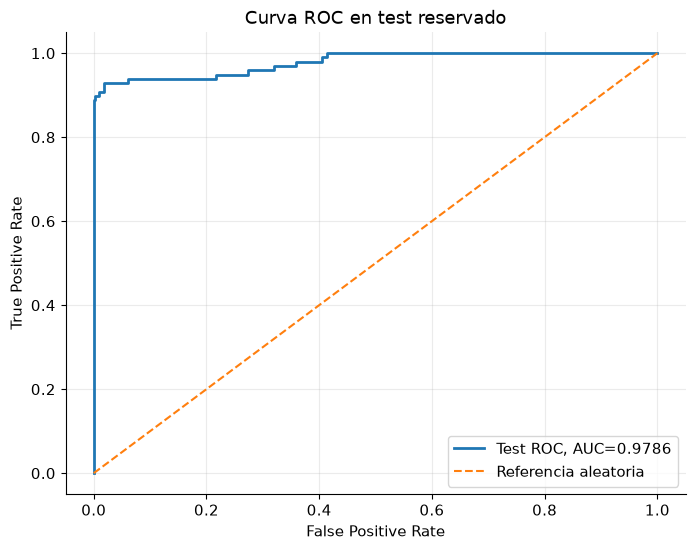

,candidate_model,policy,threshold,precision,recall,f1,tn,fp,fn,tp,predicted_positive_count,predicted_positive_rate
0,lightgbm_base_class_weight,default_0.50,0.500000,0.831683,0.857143,0.844221,56847,17,14,84,101,0.001773
1,lightgbm_base_class_weight,max_f1,0.980000,0.951807,0.806122,0.872928,56860,4,19,79,83,0.001457


,pred_no_fraud,pred_fraud
actual_no_fraud,56860,4
actual_fraud,19,79


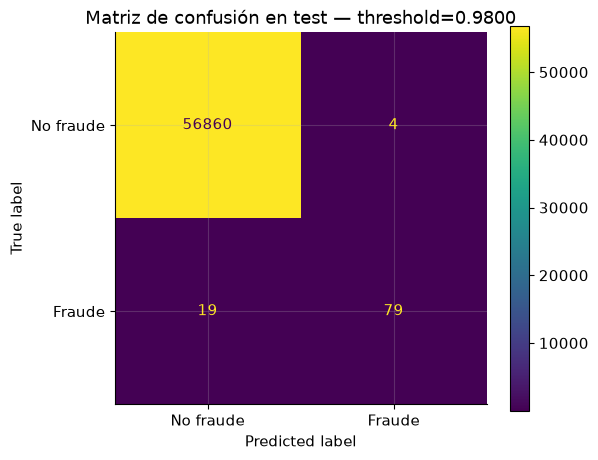


                                CLASSIFICATION REPORT — TEST SET                                
              precision    recall  f1-score   support

    no_fraud       1.00      1.00      1.00     56864
       fraud       0.95      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [30]:
# =============================================================================
# 14.2 Test curves, threshold metrics and confusion matrix
# =============================================================================

test_precision_curve, test_recall_curve, test_pr_thresholds = precision_recall_curve(y_test, y_test_scores)
test_fpr_curve, test_tpr_curve, test_roc_thresholds = roc_curve(y_test, y_test_scores)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(test_recall_curve, test_precision_curve, linewidth=2, label=f"Test PR, AP={TEST_PR_AUC:.4f}")
ax.axhline(float(y_test.mean()), linestyle="--", linewidth=1.5, label="Prevalencia test")
ax.set_title("Curva Precision-Recall en test reservado")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(test_fpr_curve, test_tpr_curve, linewidth=2, label=f"Test ROC, AUC={TEST_ROC_AUC:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Referencia aleatoria")
ax.set_title("Curva ROC en test reservado")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

test_default_threshold_metrics = compute_binary_policy_metrics(y_test, y_test_scores, 0.50)
test_selected_threshold_metrics = compute_binary_policy_metrics(y_test, y_test_scores, SELECTED_THRESHOLD)

test_threshold_comparison = pd.DataFrame([
    {"candidate_model": CANDIDATE_MODEL_NAME, "policy": "default_0.50", **test_default_threshold_metrics},
    {"candidate_model": CANDIDATE_MODEL_NAME, "policy": THRESHOLD_POLICY, **test_selected_threshold_metrics},
])

display(test_threshold_comparison)

y_test_pred_selected = (y_test_scores >= SELECTED_THRESHOLD).astype(int)
test_cm_selected = confusion_matrix(y_test, y_test_pred_selected, labels=[NEGATIVE_LABEL, POSITIVE_LABEL])
test_cm_selected_df = pd.DataFrame(
    test_cm_selected,
    index=["actual_no_fraud", "actual_fraud"],
    columns=["pred_no_fraud", "pred_fraud"],
)

display(test_cm_selected_df)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=test_cm_selected, display_labels=["No fraude", "Fraude"]).plot(ax=ax, values_format="d")
ax.set_title(f"Matriz de confusión en test — threshold={SELECTED_THRESHOLD:.4f}")
plt.show()

print_section("CLASSIFICATION REPORT — TEST SET")
print(classification_report(y_test, y_test_pred_selected, target_names=["no_fraud", "fraud"], zero_division=0))


## 15. Tabla final, importancia de variables y conclusión defendible


---
### 🧭 Guía docente — tabla de evidencia e importancia de variables (celda 15.1)

**`final_evidence_table`** resume la trazabilidad en 3 filas: selección por CV → diseño del umbral con OOF → verificación en test. Los `NaN` son intencionales (por ejemplo, en la etapa de CV no se fijó umbral).

**Importancia de variables:** `extract_feature_importance` saca el modelo del pipeline si es necesario y lee su importancia nativa.

**⚠️ Ojo, preguntas y trampas:**
- Cada librería mide la importancia distinto por defecto: XGBoost (sklearn API) usa **gain** (cuánto mejora la pérdida cada variable), LightGBM usa **split** (cuántas veces se usa la variable), CatBoost usa *PredictionValuesChange*. **No se pueden comparar entre familias.**
- La importancia nativa de árboles tiende a favorecer variables continuas con muchos valores posibles y se reparte de forma arbitraria entre variables correlacionadas.
- `V1`–`V28` son componentes PCA anonimizadas: saber que "V14 es importante" **no tiene interpretación de negocio**. Es una limitación del dataset, no del método.
- Para interpretación más seria: *permutation importance* o SHAP (fuera del alcance de la sesión, buen tema de extensión).

,stage,model,pr_auc,pr_auc_std,roc_auc,threshold,precision,recall,f1,predicted_positive_count,predicted_positive_rate
0,cross_validation_selection,lightgbm_base_class_weight,0.855418,0.022684,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,out_of_fold_threshold_design,lightgbm_base_class_weight,0.854294,NaN,0.979145,0.980000,0.947692,0.781726,0.856745,325.000000,0.001426
2,reserved_test_final_evaluation,lightgbm_base_class_weight,0.880180,NaN,0.978573,0.980000,0.951807,0.806122,0.872928,83.000000,0.001457


,feature,importance,importance_normalized
0,V4,481,0.064133
1,V14,446,0.059467
2,V26,348,0.046400
3,Time,324,0.043200
4,V12,323,0.043067
5,V7,304,0.040533
6,V24,283,0.037733
7,V10,281,0.037467
8,V13,274,0.036533
9,V11,266,0.035467


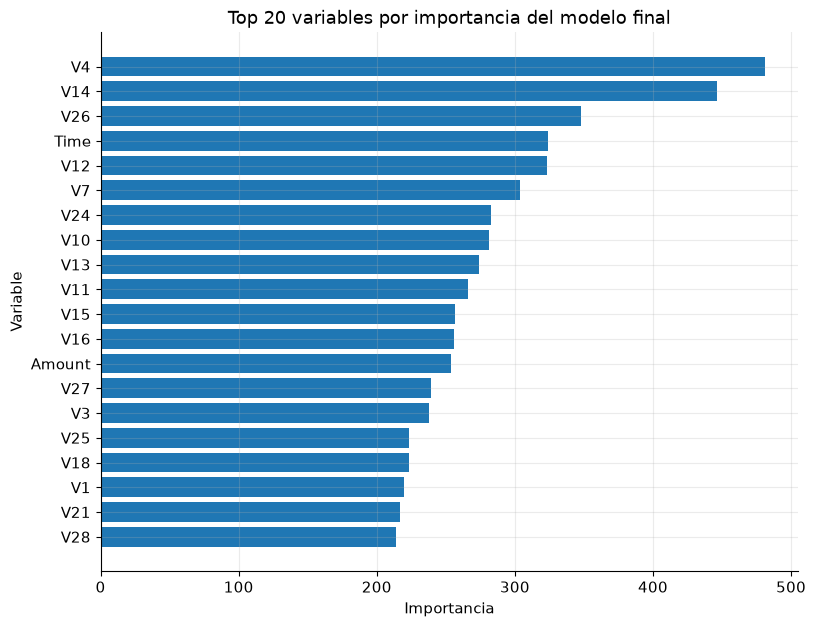

In [31]:
# =============================================================================
# 15.1 Final evidence table and feature importance
# =============================================================================

final_evidence_table = pd.DataFrame([
    {
        "stage": "cross_validation_selection",
        "model": CANDIDATE_MODEL_NAME,
        "pr_auc": CANDIDATE_PR_AUC_MEAN,
        "pr_auc_std": CANDIDATE_PR_AUC_STD,
        "roc_auc": np.nan,
        "threshold": np.nan,
        "precision": np.nan,
        "recall": np.nan,
        "f1": np.nan,
        "predicted_positive_count": np.nan,
        "predicted_positive_rate": np.nan,
    },
    {
        "stage": "out_of_fold_threshold_design",
        "model": CANDIDATE_MODEL_NAME,
        "pr_auc": OOF_PR_AUC,
        "pr_auc_std": np.nan,
        "roc_auc": OOF_ROC_AUC,
        "threshold": SELECTED_THRESHOLD,
        "precision": selected_threshold_metrics["precision"],
        "recall": selected_threshold_metrics["recall"],
        "f1": selected_threshold_metrics["f1"],
        "predicted_positive_count": selected_threshold_metrics["predicted_positive_count"],
        "predicted_positive_rate": selected_threshold_metrics["predicted_positive_rate"],
    },
    {
        "stage": "reserved_test_final_evaluation",
        "model": CANDIDATE_MODEL_NAME,
        "pr_auc": TEST_PR_AUC,
        "pr_auc_std": np.nan,
        "roc_auc": TEST_ROC_AUC,
        "threshold": SELECTED_THRESHOLD,
        "precision": test_selected_threshold_metrics["precision"],
        "recall": test_selected_threshold_metrics["recall"],
        "f1": test_selected_threshold_metrics["f1"],
        "predicted_positive_count": test_selected_threshold_metrics["predicted_positive_count"],
        "predicted_positive_rate": test_selected_threshold_metrics["predicted_positive_rate"],
    },
])

display(final_evidence_table)


def get_final_estimator_from_pipeline_or_model(fitted_estimator: Any) -> Any:
    """Extract the final estimator from a pipeline if needed."""
    if hasattr(fitted_estimator, "named_steps"):
        if "model" in fitted_estimator.named_steps:
            return fitted_estimator.named_steps["model"]
        return list(fitted_estimator.named_steps.values())[-1]
    return fitted_estimator


def extract_feature_importance(fitted_estimator: Any, feature_names: List[str]) -> pd.DataFrame:
    """Extract feature importance when supported."""
    final_estimator = get_final_estimator_from_pipeline_or_model(fitted_estimator)
    importance_values = None

    if hasattr(final_estimator, "feature_importances_"):
        importance_values = np.asarray(final_estimator.feature_importances_)
    elif hasattr(final_estimator, "get_feature_importance"):
        try:
            importance_values = np.asarray(final_estimator.get_feature_importance())
        except Exception:
            importance_values = None

    if importance_values is None or len(importance_values) != len(feature_names):
        return pd.DataFrame()

    importance_df = pd.DataFrame({"feature": feature_names, "importance": importance_values})
    total = importance_df["importance"].sum()
    importance_df["importance_normalized"] = importance_df["importance"] / total if total > 0 else np.nan
    return importance_df.sort_values("importance", ascending=False).reset_index(drop=True)


feature_importance_df = extract_feature_importance(final_model, X_train.columns.tolist())

if feature_importance_df.empty:
    print("Feature importance is not available for this final estimator.")
else:
    display(feature_importance_df.head(20))
    top_importance = feature_importance_df.head(20).sort_values("importance")
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(top_importance["feature"], top_importance["importance"])
    ax.set_title("Top 20 variables por importancia del modelo final")
    ax.set_xlabel("Importancia")
    ax.set_ylabel("Variable")
    plt.show()


---
### 🧭 Guía docente — registro final y conclusión (celda 15.2)

- `final_experiment_record`: una fila con **todo** lo que define el experimento (dataset, métrica, validación, modelo, umbral y resultados). Es la plantilla que los estudiantes deberían reproducir en su PI.
- `final_conclusion`: texto armado con f-strings. Léelo en voz alta en clase; es un modelo de cómo **redactar** una conclusión técnica: qué se eligió, con qué evidencia, qué dio en test y **qué limitaciones** tiene.

Las limitaciones que menciona son reales y conviene enfatizarlas: el umbral es ilustrativo, falta un análisis temporal (el split es aleatorio), la importancia de variables no es interpretable por la PCA, y no se revisó la calibración de las probabilidades.

In [32]:
# =============================================================================
# 15.2 Final experiment record and conclusion
# =============================================================================

final_experiment_record = pd.DataFrame([{
    "course_session": "Sesión 2 — Boosting moderno y HPO con validación correcta",
    "dataset": "Credit Card Fraud Detection",
    "candidate_model": CANDIDATE_MODEL_NAME,
    "candidate_group": CANDIDATE_MODEL_GROUP,
    "primary_metric": "average_precision / PR-AUC",
    "selection_validation": "Stratified K-Fold on training set",
    "threshold_source": "out-of-fold predictions on training set",
    "threshold_policy": THRESHOLD_POLICY,
    "selected_threshold": SELECTED_THRESHOLD,
    "cv_pr_auc_mean": CANDIDATE_PR_AUC_MEAN,
    "cv_pr_auc_std": CANDIDATE_PR_AUC_STD,
    "oof_pr_auc": OOF_PR_AUC,
    "oof_roc_auc": OOF_ROC_AUC,
    "test_pr_auc": TEST_PR_AUC,
    "test_roc_auc": TEST_ROC_AUC,
    "test_precision": test_selected_threshold_metrics["precision"],
    "test_recall": test_selected_threshold_metrics["recall"],
    "test_f1": test_selected_threshold_metrics["f1"],
    "test_predicted_positive_count": test_selected_threshold_metrics["predicted_positive_count"],
    "test_predicted_positive_rate": test_selected_threshold_metrics["predicted_positive_rate"],
    "test_set_used_for_model_selection": False,
    "final_fit_time_sec": final_fit_time_sec,
}])

display(final_experiment_record)

results_registry["test_ranking_summary"] = test_ranking_summary
results_registry["test_threshold_comparison"] = test_threshold_comparison
results_registry["final_evidence_table"] = final_evidence_table
results_registry["feature_importance_df"] = feature_importance_df
results_registry["final_experiment_record"] = final_experiment_record

final_conclusion = f"""
Conclusión técnica final:

Bajo Stratified K-Fold en el conjunto de entrenamiento y usando
average_precision / PR-AUC como métrica principal, el candidato seleccionado fue:

    {CANDIDATE_MODEL_NAME}

Evidencia durante selección:
    CV PR-AUC promedio = {CANDIDATE_PR_AUC_MEAN:.6f}
    CV PR-AUC std      = {CANDIDATE_PR_AUC_STD:.6f}

Evidencia out-of-fold:
    OOF PR-AUC         = {OOF_PR_AUC:.6f}
    OOF ROC-AUC        = {OOF_ROC_AUC:.6f}

Política de threshold:
    policy             = {THRESHOLD_POLICY}
    selected_threshold = {SELECTED_THRESHOLD:.6f}

Evaluación final en test reservado:
    Test PR-AUC        = {TEST_PR_AUC:.6f}
    Test ROC-AUC       = {TEST_ROC_AUC:.6f}
    Test precision     = {test_selected_threshold_metrics['precision']:.6f}
    Test recall        = {test_selected_threshold_metrics['recall']:.6f}
    Test F1            = {test_selected_threshold_metrics['f1']:.6f}
    Alertas en test    = {test_selected_threshold_metrics['predicted_positive_count']:,}
    Tasa de alertas    = {test_selected_threshold_metrics['predicted_positive_rate']:.6f}

Lectura metodológica:
    Esta conclusión es defendible porque el modelo, los hiperparámetros,
    la estrategia de desbalance y el threshold fueron seleccionados antes
    de evaluar el test set. El test set se usó solo como verificación final.

Limitaciones:
    - El threshold usado es una política ilustrativa, no necesariamente una política
      de negocio final.
    - En fraude real habría que incorporar costos, capacidad de revisión y análisis
      temporal o por entidad.
    - La importancia de variables debe leerse con cautela porque el dataset está
      anonimizado y contiene variables transformadas.
    - Antes de operación o PI final, conviene revisar calibración, estabilidad temporal,
      leakage transaccional y análisis de errores.
"""

print(final_conclusion)


,course_session,dataset,candidate_model,candidate_group,primary_metric,selection_validation,threshold_source,threshold_policy,selected_threshold,cv_pr_auc_mean,cv_pr_auc_std,oof_pr_auc,oof_roc_auc,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,test_predicted_positive_count,test_predicted_positive_rate,test_set_used_for_model_selection,final_fit_time_sec
0,Sesión 2 — Boosting moderno y HPO con validaci...,Credit Card Fraud Detection,lightgbm_base_class_weight,boosting_base,average_precision / PR-AUC,Stratified K-Fold on training set,out-of-fold predictions on training set,max_f1,0.980000,0.855418,0.022684,0.854294,0.979145,0.880180,0.978573,0.951807,0.806122,0.872928,83,0.001457,False,1.629226



Conclusión técnica final:

Bajo Stratified K-Fold en el conjunto de entrenamiento y usando
average_precision / PR-AUC como métrica principal, el candidato seleccionado fue:

    lightgbm_base_class_weight

Evidencia durante selección:
    CV PR-AUC promedio = 0.855418
    CV PR-AUC std      = 0.022684

Evidencia out-of-fold:
    OOF PR-AUC         = 0.854294
    OOF ROC-AUC        = 0.979145

Política de threshold:
    policy             = max_f1
    selected_threshold = 0.980000

Evaluación final en test reservado:
    Test PR-AUC        = 0.880180
    Test ROC-AUC       = 0.978573
    Test precision     = 0.951807
    Test recall        = 0.806122
    Test F1            = 0.872928
    Alertas en test    = 83
    Tasa de alertas    = 0.001457

Lectura metodológica:
    Esta conclusión es defendible porque el modelo, los hiperparámetros,
    la estrategia de desbalance y el threshold fueron seleccionados antes
    de evaluar el test set. El test set se usó solo como verificación final

## 16. Checklist metodológico final

Antes de declarar una selección como defendible, revisa:

- [x] El dataset fue auditado antes de modelar.
- [x] La clase positiva rara fue identificada explícitamente.
- [x] `accuracy` no fue usada como métrica principal.
- [x] Se creó un test set estratificado y reservado.
- [x] Los baselines se evaluaron antes de modelos complejos.
- [x] XGBoost, LightGBM y CatBoost se compararon bajo el mismo protocolo cuando estuvieron disponibles.
- [x] HPO optimizó `average_precision`, no una métrica débil para desbalance.
- [x] La validación vivió dentro de la función objetivo de HPO.
- [x] SMOTE, cuando se usó, vivió dentro del pipeline y dentro de cada fold.
- [x] El candidato final se seleccionó por evidencia de CV.
- [x] El threshold se seleccionó con out-of-fold predictions.
- [x] El test set se usó solo al final.
- [x] La conclusión nombra métrica, validación, modelo, threshold y limitaciones.


## 17. Auditoría final del notebook

Esta auditoría valida estructura, objetos críticos, integridad de datos, leakage, métricas y alineación pedagógica.


---
### 🧭 Guía docente — qué hacen realmente las auditorías

Las celdas 17.x verifican que el notebook se ejecutó completo y en orden.

**⚠️ Ojo, para no quedar mal ante un estudiante crítico:** varias de estas "auditorías" son **autodeclaradas**, no verificaciones reales:

| Auditoría | ¿Verifica algo de verdad? |
|---|---|
| 17.1 Objetos requeridos | Sí: comprueba que existen las variables (detecta si se saltó una celda). |
| 17.2 Integridad de datos | Sí: tamaños, solapamiento train/test, presencia de positivos. |
| 17.2 Leakage | **Parcialmente.** `test_set_used == False` es un valor **escrito a mano** antes; el chequeo de SMOTE solo verifica que sea un pipeline. |
| 17.2 Rango de métricas | Sí, pero básico (valores finitos entre 0 y 1). |
| 17.3 Alineación pedagógica | **No.** La columna `status` es `"satisfied"` escrita a mano; siempre pasa. |

La verdadera garantía contra el leakage es **el diseño del código** (el test solo aparece en la sección 14), no estas tablas. Son útiles como **documentación** y como checklist, y es sano decirlo así en clase.

In [33]:
# =============================================================================
# 17.1 Required objects audit
# =============================================================================

def audit_required_objects(object_names: List[str], scope: Dict[str, Any]) -> pd.DataFrame:
    """Audit whether required objects exist."""
    return pd.DataFrame([
        {
            "object": name,
            "exists": name in scope,
            "type": type(scope[name]).__name__ if name in scope else None,
        }
        for name in object_names
    ])


required_objects = [
    "RANDOM_STATE", "TARGET_COL", "df", "X", "y", "X_train", "X_test", "y_train", "y_test",
    "cv", "CLASSIFICATION_CV_SCORING", "baseline_results", "boosting_base_results",
    "HPO_FAMILY", "best_hpo_params", "best_hpo_model", "tuned_report", "strategy_results",
    "final_cv_comparison", "candidate_model", "CANDIDATE_MODEL_NAME", "oof_scores",
    "OOF_PR_AUC", "OOF_ROC_AUC", "SELECTED_THRESHOLD", "THRESHOLD_POLICY",
    "final_model", "y_test_scores", "TEST_PR_AUC", "TEST_ROC_AUC",
    "final_evidence_table", "final_experiment_record", "results_registry", "model_registry",
]

required_audit = audit_required_objects(required_objects, globals())
display(required_audit)

missing_required_objects = required_audit.query("exists == False")
if not missing_required_objects.empty:
    raise RuntimeError("Some required objects are missing. Run all previous cells in order.")

print("Required objects audit passed.")


,object,exists,type
0,RANDOM_STATE,True,int
1,TARGET_COL,True,str
2,df,True,DataFrame
3,X,True,DataFrame
4,y,True,Series
5,X_train,True,DataFrame
6,X_test,True,DataFrame
7,y_train,True,Series
8,y_test,True,Series
9,cv,True,StratifiedKFold


Required objects audit passed.


In [34]:
# =============================================================================
# 17.2 Data integrity, leakage and metric audits
# =============================================================================

data_integrity_audit = pd.DataFrame([
    {
        "check": "X_train and y_train length match",
        "passed": len(X_train) == len(y_train),
        "details": f"{len(X_train)} vs {len(y_train)}",
    },
    {
        "check": "X_test and y_test length match",
        "passed": len(X_test) == len(y_test),
        "details": f"{len(X_test)} vs {len(y_test)}",
    },
    {
        "check": "train/test index overlap is empty",
        "passed": len(set(X_train.index).intersection(set(X_test.index))) == 0,
        "details": f"overlap={len(set(X_train.index).intersection(set(X_test.index)))}",
    },
    {
        "check": "positive class exists in train",
        "passed": int(y_train.sum()) > 0,
        "details": f"positive_count={int(y_train.sum())}",
    },
    {
        "check": "positive class exists in test",
        "passed": int(y_test.sum()) > 0,
        "details": f"positive_count={int(y_test.sum())}",
    },
])

display(data_integrity_audit)
if not data_integrity_audit["passed"].all():
    raise RuntimeError("Data integrity audit failed.")

leakage_audit = pd.DataFrame([
    {
        "check": "test set was not used for model selection",
        "passed": bool(final_experiment_record["test_set_used_for_model_selection"].iloc[0] == False),
        "evidence": "final_experiment_record",
    },
    {
        "check": "threshold selected before test",
        "passed": bool(pretest_decision_record["test_set_used"].iloc[0] == False),
        "evidence": "pretest_decision_record",
    },
    {
        "check": "SMOTE strategies, if used, are pipelines",
        "passed": all(hasattr(model, "steps") for name, model in strategy_models.items() if "smote" in name),
        "evidence": "strategy_models",
    },
])

display(leakage_audit)
if not leakage_audit["passed"].all():
    raise RuntimeError("Leakage audit failed.")

metric_values_to_check = {
    "CANDIDATE_PR_AUC_MEAN": CANDIDATE_PR_AUC_MEAN,
    "CANDIDATE_PR_AUC_STD": CANDIDATE_PR_AUC_STD,
    "OOF_PR_AUC": OOF_PR_AUC,
    "OOF_ROC_AUC": OOF_ROC_AUC,
    "SELECTED_THRESHOLD": SELECTED_THRESHOLD,
    "TEST_PR_AUC": TEST_PR_AUC,
    "TEST_ROC_AUC": TEST_ROC_AUC,
    "test_precision": test_selected_threshold_metrics["precision"],
    "test_recall": test_selected_threshold_metrics["recall"],
    "test_f1": test_selected_threshold_metrics["f1"],
}

metric_consistency_audit = pd.DataFrame([
    {
        "metric": name,
        "value": value,
        "is_finite": bool(np.isfinite(value)),
        "in_expected_range": bool(value >= 0 if name == "CANDIDATE_PR_AUC_STD" else 0 <= value <= 1),
        "passed": bool(np.isfinite(value) and (value >= 0 if name == "CANDIDATE_PR_AUC_STD" else 0 <= value <= 1)),
    }
    for name, value in metric_values_to_check.items()
])

display(metric_consistency_audit)
if not metric_consistency_audit["passed"].all():
    raise RuntimeError("Metric consistency audit failed.")

print("Data, leakage and metric audits passed.")


,check,passed,details
0,X_train and y_train length match,True,227845 vs 227845
1,X_test and y_test length match,True,56962 vs 56962
2,train/test index overlap is empty,True,overlap=0
3,positive class exists in train,True,positive_count=394
4,positive class exists in test,True,positive_count=98


,check,passed,evidence
0,test set was not used for model selection,True,final_experiment_record
1,threshold selected before test,True,pretest_decision_record
2,"SMOTE strategies, if used, are pipelines",True,strategy_models


,metric,value,is_finite,in_expected_range,passed
0,CANDIDATE_PR_AUC_MEAN,0.855418,True,True,True
1,CANDIDATE_PR_AUC_STD,0.022684,True,True,True
2,OOF_PR_AUC,0.854294,True,True,True
3,OOF_ROC_AUC,0.979145,True,True,True
4,SELECTED_THRESHOLD,0.980000,True,True,True
5,TEST_PR_AUC,0.880180,True,True,True
6,TEST_ROC_AUC,0.978573,True,True,True
7,test_precision,0.951807,True,True,True
8,test_recall,0.806122,True,True,True
9,test_f1,0.872928,True,True,True


Data, leakage and metric audits passed.


In [35]:
# =============================================================================
# 17.3 Pedagogical alignment audit
# =============================================================================

pedagogical_alignment = pd.DataFrame([
    {"requirement": "Credit Card Fraud Detection dataset", "evidence": "dataset resolver + target audit", "status": "satisfied"},
    {"requirement": "rare-event metric logic", "evidence": "class balance + PR-AUC as primary metric", "status": "satisfied"},
    {"requirement": "baselines before boosting", "evidence": "baseline_results", "status": "satisfied"},
    {"requirement": "XGBoost/LightGBM/CatBoost comparison", "evidence": "boosting_base_results when libraries are available", "status": "satisfied"},
    {"requirement": "HPO with correct validation", "evidence": "objective uses Stratified K-Fold and average_precision", "status": "satisfied"},
    {"requirement": "Optuna fallback", "evidence": "RandomizedSearchCV fallback", "status": "satisfied"},
    {"requirement": "HPO diagnostics", "evidence": "normalized_hpo_report and plots", "status": "satisfied"},
    {"requirement": "class weights vs SMOTE", "evidence": "strategy_results + safe SMOTE pipeline", "status": "satisfied"},
    {"requirement": "threshold as policy", "evidence": "OOF threshold sweep", "status": "satisfied"},
    {"requirement": "test only at the end", "evidence": "pretest_decision_record + final_experiment_record", "status": "satisfied"},
    {"requirement": "defensible conclusion", "evidence": "final_evidence_table + final_conclusion", "status": "satisfied"},
])

display(pedagogical_alignment)

if not (pedagogical_alignment["status"] == "satisfied").all():
    raise RuntimeError("Pedagogical alignment audit failed.")

complexity_progression = pd.DataFrame([
    {"order": 1, "stage": "contract", "passed": True},
    {"order": 2, "stage": "environment", "passed": True},
    {"order": 3, "stage": "dataset audit", "passed": True},
    {"order": 4, "stage": "baselines", "passed": "baseline_results" in globals()},
    {"order": 5, "stage": "boosting base", "passed": "boosting_base_results" in globals()},
    {"order": 6, "stage": "hpo", "passed": "best_hpo_params" in globals()},
    {"order": 7, "stage": "hpo diagnostics", "passed": "normalized_hpo_report" in globals()},
    {"order": 8, "stage": "imbalance strategies", "passed": "strategy_results" in globals()},
    {"order": 9, "stage": "threshold policy", "passed": "threshold_sweep_df" in globals()},
    {"order": 10, "stage": "test final", "passed": "TEST_PR_AUC" in globals()},
    {"order": 11, "stage": "methodological close", "passed": "final_experiment_record" in globals()},
])

display(complexity_progression)
if not complexity_progression["passed"].all():
    raise RuntimeError("Complexity progression audit failed.")

NOTEBOOK_FINAL_AUDIT_PASSED = True

print_section("FINAL AUDIT PASSED")
print("The notebook is methodologically complete under the Session 2 contract.")


,requirement,evidence,status
0,Credit Card Fraud Detection dataset,dataset resolver + target audit,satisfied
1,rare-event metric logic,class balance + PR-AUC as primary metric,satisfied
2,baselines before boosting,baseline_results,satisfied
3,XGBoost/LightGBM/CatBoost comparison,boosting_base_results when libraries are avail...,satisfied
4,HPO with correct validation,objective uses Stratified K-Fold and average_p...,satisfied
5,Optuna fallback,RandomizedSearchCV fallback,satisfied
6,HPO diagnostics,normalized_hpo_report and plots,satisfied
7,class weights vs SMOTE,strategy_results + safe SMOTE pipeline,satisfied
8,threshold as policy,OOF threshold sweep,satisfied
9,test only at the end,pretest_decision_record + final_experiment_record,satisfied


,order,stage,passed
0,1,contract,True
1,2,environment,True
2,3,dataset audit,True
3,4,baselines,True
4,5,boosting base,True
5,6,hpo,True
6,7,hpo diagnostics,True
7,8,imbalance strategies,True
8,9,threshold policy,True
9,10,test final,True



                                       FINAL AUDIT PASSED                                       
The notebook is methodologically complete under the Session 2 contract.


## 18. Ejercicios de extensión

### Ejercicio 1 — Rediseñar la política de threshold

Cambia `THRESHOLD_POLICY` por:

```text
max_precision_with_recall_floor
```

y define otro `TARGET_RECALL_FLOOR`. Responde:

- ¿cuánto sube o baja la precision?
- ¿cuántas alertas se generan?
- ¿qué riesgo operativo cambia?

### Ejercicio 2 — Comparar otra familia en HPO

Si tienes tiempo de ejecución suficiente, fuerza `HPO_FAMILY` a otra familia disponible y repite el bloque de HPO.

Responde:

- ¿la mejora fue real o marginal?
- ¿cambió la variabilidad entre folds?
- ¿la familia justifica su costo computacional?

### Ejercicio 3 — Auditar SMOTE

Cambia `sampling_strategy` en el pipeline de SMOTE:

```text
0.05, 0.10, 0.20
```

y evalúa si más oversampling realmente mejora PR-AUC o solo aumenta complejidad.

### Ejercicio 4 — Llevarlo al PI

Para un problema supervisado tabular de tu PI, escribe:

- métrica principal;
- esquema de validación;
- baseline serio;
- familia boosted candidata;
- estrategia de desbalance;
- política de threshold o criterio de decisión;
- evidencia mínima para declarar un modelo defendible.


---
### 🧭 Guía docente — pistas para los ejercicios

**Ejercicio 1 — Política de umbral.** Cambiar en la celda 13.2:
```python
THRESHOLD_POLICY = "max_precision_with_recall_floor"
TARGET_RECALL_FLOOR = 0.85
```
y volver a ejecutar desde 13.2 hasta el final. Al exigir más recall, el umbral **baja**, aparecen **más alertas** y la precisión cae. Si el piso es demasiado alto, la función lanza `ValueError("No threshold satisfies recall floor.")`: es la señal de que el modelo no puede lograrlo con esa grilla. Riesgo operativo: más carga en el equipo de revisión, menos fraude perdido.

*Nota:* cambiar el umbral y volver a mirar el test **es exactamente lo que no se debe hacer** en un proyecto real. En el ejercicio vale porque es exploratorio; conviene decirlo.

**Ejercicio 2 — Otra familia en HPO.** Después de ejecutar la celda 7.3, forzar:
```python
HPO_FAMILY = "lightgbm"   # o "catboost"
```
y re-ejecutar desde la 8.1. Comparar la mejora del tuneado respecto a su propio modelo base (no respecto a XGBoost), y comparar el `fit_time_mean`. CatBoost será notablemente más lento.

**Ejercicio 3 — Auditar SMOTE.** En la celda 11.1, cambiar `sampling_strategy=0.10` por 0.05 y 0.20 en las dos líneas de SMOTE. Resultado habitual: el PR-AUC cambia poco y el tiempo crece con más oversampling. Conclusión esperada: más datos sintéticos ≠ mejor ordenamiento.

**Ejercicio 4 — PI.** Que respondan en una tabla con las 7 filas pedidas. Un buen criterio de evaluación: ¿la métrica que eligieron corresponde al costo real de los errores en su problema?

## Cierre del notebook

Este notebook materializa la idea central de la sesión:

> Boosting moderno es fuerte cuando el experimento que lo sostiene también es fuerte.

La calidad de la decisión no proviene de usar XGBoost, LightGBM, CatBoost u Optuna por sí solos.

Proviene de construir una comparación donde:

- la métrica corresponde al problema;
- la validación protege la conclusión;
- el tuning no usa test;
- el desbalance se trata como hipótesis, no como receta;
- el threshold se decide con evidencia;
- el resultado final se presenta con límites claros.

Ese es el estándar mínimo para llevar un modelo boosted al taller modular o al PI.


---
# 📎 Anexo para el docente

## A. Preguntas frecuentes de estudiantes (con respuesta corta)

**1. ¿Qué diferencia hay entre `average_precision` y "PR-AUC"?**
`average_precision` resume la curva PR como $\sum_n (R_n - R_{n-1})\,P_n$ (suma escalonada), sin interpolar. Es la forma recomendada por scikit-learn de calcular "el área bajo la curva PR". En la práctica se usan como sinónimos.

**2. ¿Por qué no usar ROC-AUC si también es independiente del umbral?**
Porque la tasa de falsos positivos (FPR) se divide por el número enorme de negativos: 1 % de FPR parece poco, pero son miles de falsas alarmas. PR-AUC se enfoca en la clase positiva y en la precisión, que es lo que importa operativamente.

**3. ¿Por qué no usamos early stopping?**
Porque requiere un conjunto de validación dentro de cada fold y complica el código. Es la forma estándar de escoger `n_estimators` en la práctica; aquí se tunea directamente como hiperparámetro.

**4. ¿Los scores del modelo son probabilidades reales?**
No necesariamente. Con pesos de clase o SMOTE están **sesgados hacia arriba**. Si se necesitan probabilidades calibradas (por ejemplo, para calcular pérdidas esperadas), hay que calibrar (`CalibratedClassifierCV`). Para **ordenar** y fijar un umbral no hace falta.

**5. ¿Por qué el mejor score del HPO es más alto que el del modelo tuneado en CV?**
Sesgo del ganador (el máximo de muchas estimaciones ruidosas es optimista), más la diferencia de datos (submuestra y 3 folds vs 5 folds con todo el train).

**6. ¿Por qué el candidato ganador puede no tener pesos ni SMOTE?**
Porque PR-AUC mide ordenamiento y pesos/SMOTE cambian principalmente la escala de los scores. El desbalance se atiende con la métrica y el umbral.

**7. ¿Qué es mejor, más trials o más folds?**
Más folds = cada evaluación es más confiable. Más trials = se explora más. Con presupuesto fijo, evaluaciones muy ruidosas hacen que Optuna persiga ruido; por eso el modo lento aumenta ambos.

**8. ¿Por qué no se hace GridSearch?**
El número de combinaciones crece exponencialmente con los hiperparámetros (9 hiperparámetros × 5 valores = ~2 millones). Random search y TPE cubren mejor el espacio con el mismo presupuesto.

**9. ¿SMOTE siempre es malo?**
No. Es una hipótesis. Puede ayudar a modelos que sufren con pocos positivos (por ejemplo, algunos modelos lineales o kNN). Con boosting y una buena métrica, frecuentemente no aporta. Lo inaceptable es aplicarlo **fuera** del CV.

**10. ¿Por qué `Time` está como variable?**
Porque el dataset lo trae. Es discutible: en producción, "segundos desde el inicio del dataset" no tiene sentido. Un buen ejercicio es quitarla o transformarla en hora del día.

## B. Glosario rápido

| Término | Definición breve |
|---|---|
| Boosting | Ensemble secuencial donde cada modelo corrige los errores del conjunto anterior |
| Learning rate ($\eta$) | Factor que reduce cada corrección; más bajo = más árboles necesarios, más estable |
| HPO | *Hyperparameter optimization*: búsqueda automática de hiperparámetros |
| TPE | Sampler de Optuna que modela dónde están los trials buenos para proponer los siguientes |
| Stratified K-Fold | CV que mantiene la proporción de clases en cada fold |
| OOF | *Out-of-fold*: predicción para cada fila hecha por el modelo que no la vio |
| PR-AUC / AP | Resumen de la curva precisión–recall; referencia de azar = prevalencia |
| Threshold / umbral | Valor de corte que convierte un score en decisión |
| `scale_pos_weight` | Multiplicador del peso de los positivos en la pérdida (≈ negativos/positivos) |
| SMOTE | Oversampling sintético por interpolación entre vecinos de la clase minoritaria |
| Leakage | Información de validación/test que se filtra al entrenamiento e infla los resultados |
| Winner's curse | El mejor de muchos candidatos ruidosos es sistemáticamente optimista |
| Nested CV | CV externo para evaluar + CV interno para tunear; evita el optimismo del HPO |

## C. Si algo falla en clase

| Síntoma | Causa probable | Solución |
|---|---|---|
| `FileNotFoundError: creditcard.csv` | No se subió el dataset | Subirlo a `/content/` (Colab) o a la carpeta del notebook |
| `Cannot clone object CatBoostClassifier ... class_weights` | Notebook original con CatBoost reciente | Usar esta versión (`scale_pos_weight`) |
| `NameError: ... is not defined` | Se saltó o falló una celda anterior | Revisar el **primer** error hacia arriba; *Run all* desde el inicio |
| La tabla muestra `available=False` | Librería no instalada | Descomentar la celda 2.1, ejecutar y reiniciar el kernel |
| Celdas muy lentas / Colab se desconecta | Poca CPU | Mantener `FAST_DEMO_MODE=True`; tener el notebook pre-ejecutado |
| Resultados distintos a los de un estudiante | Versiones distintas de librerías o hardware | Normal: pequeñas diferencias numéricas; la **metodología** es lo que se evalúa |

## D. Tiempos de ejecución

Prueba de ejecución completa de esta versión con `FAST_DEMO_MODE = True`, sobre un dataset **sintético del mismo tamaño y esquema** que `creditcard.csv` (284 807 filas, 492 fraudes) en una máquina con **2 núcleos de CPU** (parecido a Colab gratuito):

- Notebook completo: **≈ 6 minutos**, sin errores.
- HPO con Optuna (15 trials): **≈ 1.2 minutos**.
- Lo más costoso después del HPO: la comparación de familias (7.2) y la de estrategias de desbalance (11.2), sobre todo las variantes con SMOTE y CatBoost.

Con el dataset real los tiempos deberían ser del mismo orden, pero pueden variar según la máquina. Con `FAST_DEMO_MODE = False` (50 trials × 5 folds con todos los datos), cuenta con bastante más tiempo: ejecútalo antes y no en vivo.

**Los números de esta guía** (PR-AUC esperados, etc.) son orientativos. Los valores exactos dependen de las versiones de las librerías; lo que se mantiene es el **patrón** (boosting > logística >> dummy; ROC-AUC alto para todos; umbral óptimo lejos de 0.5).

In [36]:
# =============================================================================
# End of notebook
# =============================================================================

print_section("FIN DEL NOTEBOOK")
print("Boosting moderno y optimización de hiperparámetros con validación correcta")
print("Revisa final_experiment_record para la síntesis final del experimento.")



                                        FIN DEL NOTEBOOK                                        
Boosting moderno y optimización de hiperparámetros con validación correcta
Revisa final_experiment_record para la síntesis final del experimento.
